# MNIST 次元削減の復元精度・プライバシー攻撃 実験

このノートブックでは、`dimensionality_reduction.py` と `anchor_utils.py` を用いて、
次元削減後の表現から元の特徴量をどの程度復元できるか、および将来的なプライバシー攻撃の実験用の枠組みを用意します。

基本設定は `base_config` で与えられた MNIST 用の設定を使用します。


# 局所流出

In [1]:
import numpy as np

In [2]:
# ノートブックの最初でリポジトリ直下に移動
import os
from pathlib import Path

repo_root = Path.cwd()
if not (repo_root / "input").exists():
    for p in repo_root.parents:
        if (p / "input").exists():
            repo_root = p
            break

os.chdir(repo_root)
print("CWD:", os.getcwd())


CWD: /Users/suetake/git-repos/takano_labo/dca


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

def show_original_vs_recon(X_true, X_recon, n=10, y=None, labels=None):
    """
    X_true, X_recon: (N, 784)
    y:              (N,)  元のラベル（任意）
    labels:         ラベルのリストを指定したら、その順で最大5個だけ可視化
    """
    if labels is not None and y is not None:
        # ラベル順に最大5個だけ
        labels = list(labels)[:5]
        fig, axes = plt.subplots(2, len(labels), figsize=(1.5*len(labels), 3))
        for i, lab in enumerate(labels):
            idx_candidates = np.where(y == lab)[0]
            if len(idx_candidates) == 0:
                # そのラベルが無ければ空白
                axes[0, i].axis("off")
                axes[1, i].axis("off")
                axes[0, i].set_title(f"{lab}(none)")
                continue
            k = idx_candidates[0]

            orig = X_true[k].reshape(28, 28)
            recon = X_recon[k].reshape(28, 28)

            axes[0, i].imshow(orig, cmap="gray")
            axes[0, i].axis("off")
            axes[0, i].set_title(f"元データ {lab}")

            axes[1, i].imshow(recon, cmap="gray")
            axes[1, i].axis("off")
            axes[1, i].set_title("復元データ")
        plt.tight_layout()
        plt.show()
        return

    # それ以外（labels 指定なし）の場合はランダムに n 個
    idx = np.random.choice(len(X_true), size=n, replace=False)
    fig, axes = plt.subplots(2, n, figsize=(1.5*n, 3))
    for i, k in enumerate(idx):
        orig = X_true[k].reshape(28, 28)
        recon = X_recon[k].reshape(28, 28)

        axes[0, i].imshow(orig, cmap="gray")
        axes[0, i].axis("off")
        axes[0, i].set_title("元データ")

        axes[1, i].imshow(recon, cmap="gray")
        axes[1, i].axis("off")
        axes[1, i].set_title("復元データ")

    plt.tight_layout()
    plt.show()



In [4]:
from config.config import Config

base_config_dict = {
    "name": "tutorial_mnist",
    "dataset": "mnist",
    "y_name": "target",
    "num_institution_user": 1200,
    "data_distribution": "even",
    "anchor_method": "smote",
    "public_anchor_num": 1000,
    "num_anchor_data": 500,
    "dim_intermediate": 600,
    "F_type": "svd",
    "seed": 42,
    "inter_normalization": False,
    "spill_num": 100,
    "preprocess":False,
}

base_config = Config(**base_config_dict)


In [5]:
from sklearn.metrics import pairwise_distances

def select_leak_random(A, A_tilde, spill_num, rng):
    spill_num = min(spill_num, A.shape[0])
    idx_leak = rng.choice(A.shape[0], size=spill_num, replace=False)
    return idx_leak, A[idx_leak], A_tilde[idx_leak]


def select_leak_local(A, A_tilde, X, y, a_label, spill_num):
    spill_num = min(spill_num, A.shape[0])
    Xa = X[y == a_label]
    dist_mat = pairwise_distances(A, Xa, metric="euclidean")
    min_dists_to_a = dist_mat.min(axis=1)
    idx_sorted = np.argsort(min_dists_to_a)
    idx_leak = idx_sorted[:spill_num]
    return idx_leak, A[idx_leak], A_tilde[idx_leak]


def select_leak_even(A, A_tilde, X, y, spill_num, rng):
    spill_num = min(spill_num, A.shape[0])

    # 近傍訓練データのラベルでアンカーにラベル付け
    D_anchor_train = pairwise_distances(A, X, metric="euclidean")
    nearest_idx = np.argmin(D_anchor_train, axis=1)
    anchor_labels = y[nearest_idx]

    labels = np.unique(y)
    L = len(labels)
    base_per_label = spill_num // L

    idx_leak_list = []
    for c in labels:
        anchor_idx_c = np.where(anchor_labels == c)[0]
        if len(anchor_idx_c) == 0:
            continue
        n_pick = min(base_per_label, len(anchor_idx_c))
        if n_pick > 0:
            idx_leak_list.append(rng.choice(anchor_idx_c, size=n_pick, replace=False))

    chosen = np.concatenate(idx_leak_list) if idx_leak_list else np.array([], dtype=int)
    remaining_needed = spill_num - len(chosen)
    if remaining_needed > 0:
        all_idx = np.arange(A.shape[0])
        remaining_pool = np.setdiff1d(all_idx, chosen)
        extra = rng.choice(
            remaining_pool,
            size=min(remaining_needed, len(remaining_pool)),
            replace=False,
        )
        idx_leak_list.append(extra)

    idx_leak = np.concatenate(idx_leak_list) if idx_leak_list else np.array([], dtype=int)
    return idx_leak, A[idx_leak], A_tilde[idx_leak]


def select_leak(A, A_tilde, X, y, a_label, cfg, rng):
    """cfg.spill_type に応じて leak アンカーを選ぶ統一インターフェース。"""
    spill_num = int(cfg.spill_num)
    if cfg.spill_type == "random":
        return select_leak_random(A, A_tilde, spill_num, rng)
    elif cfg.spill_type == "local":
        return select_leak_local(A, A_tilde, X, y, a_label, spill_num)
    elif cfg.spill_type == "even":
        return select_leak_even(A, A_tilde, X, y, spill_num, rng)
    else:
        # デフォルトは random
        return select_leak_random(A, A_tilde, spill_num, rng)


In [6]:

from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor


def _means(Z, X, center: bool):
    if center:
        Zm = Z.mean(axis=0, keepdims=True)
        Xm = X.mean(axis=0, keepdims=True)
    else:
        Zm = np.zeros((1, Z.shape[1]))
        Xm = np.zeros((1, X.shape[1]))
    return Zm, Xm


def reconstruct_linear_pinv_centered(A_tilde_leak, A_leak, X_tilde, center: bool = True):
    Z = np.asarray(A_tilde_leak, float)
    X = np.asarray(A_leak, float)

    Z_mean, X_mean = _means(Z, X, center)
    Zc = Z - Z_mean
    Xc = X - X_mean

    W_c, *_ = np.linalg.lstsq(Zc, Xc, rcond=None)
    X_rec = (X_tilde - Z_mean) @ W_c + X_mean
    return X_rec, W_c, Z_mean, X_mean


def reconstruct_linear_ridge(A_tilde_leak, A_leak, X_tilde, lam=1e-3, center: bool = True):
    Z = np.asarray(A_tilde_leak, float)
    X = np.asarray(A_leak, float)

    Z_mean, X_mean = _means(Z, X, center)
    Zc = Z - Z_mean
    Xc = X - X_mean

    ZTZ = Zc.T @ Zc
    k = ZTZ.shape[0]
    W = np.linalg.solve(ZTZ + lam * np.eye(k), Zc.T @ Xc)

    X_rec = (X_tilde - Z_mean) @ W + X_mean
    return X_rec, W


def reconstruct_mlp(A_tilde_leak, A_leak, X_tilde, cfg, center: bool = True):
    Z = np.asarray(A_tilde_leak, float)
    X = np.asarray(A_leak, float)

    if center:
        scaler_z = StandardScaler()
        Z_train = scaler_z.fit_transform(Z)
    else:
        scaler_z = None
        Z_train = Z

    X_mean = X.mean(axis=0, keepdims=True) if center else np.zeros((1, X.shape[1]))
    Xc = X - X_mean

    mlp = MLPRegressor(
        hidden_layer_sizes=(256,),
        activation='relu',
        solver='adam',
        max_iter=2000,
        early_stopping=True,
        validation_fraction=0.2,
        n_iter_no_change=10,
        random_state=int(cfg.seed),
    )
    mlp.fit(Z_train, Xc)

    Z_all = scaler_z.transform(X_tilde) if scaler_z is not None else X_tilde
    X_rec_c = mlp.predict(Z_all)
    X_rec_mlp = X_rec_c + X_mean
    return X_rec_mlp, mlp


def reconstruct_procrustes_pinv_style(A_tilde_leak, A_leak, X_tilde, center: bool = True):
    Z = np.asarray(A_tilde_leak, float)
    X = np.asarray(A_leak, float)

    Z_mean, X_mean = _means(Z, X, center)
    Zc = Z - Z_mean
    Xc = X - X_mean

    M = Zc.T @ Xc
    U, _, Vt = np.linalg.svd(M, full_matrices=False)
    W_ortho = U @ Vt

    X_rec = (X_tilde - Z_mean) @ W_ortho + X_mean
    return X_rec, W_ortho, Z_mean, X_mean


def reconstruct_pinv_orth(A_tilde_leak, A_leak, X_tilde, center: bool = True):
    A = np.asarray(A_leak, float)
    Z = np.asarray(A_tilde_leak, float)

    mean_Z, mean_A = _means(Z, A, center)
    A_c = A - mean_A
    Z_c = Z - mean_Z

    F_hat, *_ = np.linalg.lstsq(A_c, Z_c, rcond=None)
    mu_hat = (mean_A - mean_Z @ F_hat.T).ravel()
    X_rec = X_tilde @ F_hat.T + mu_hat
    return X_rec, F_hat, mu_hat


def reconstruct_pinv_not_orth(A_tilde_leak, A_leak, X_tilde, center: bool = True):
    A = np.asarray(A_leak, float)
    Z = np.asarray(A_tilde_leak, float)

    mean_Z, mean_A = _means(Z, A, center)
    A_c = A - mean_A
    Z_c = Z - mean_Z

    F_hat, *_ = np.linalg.lstsq(A_c, Z_c, rcond=None)
    F_hat_pinv = np.linalg.pinv(F_hat)
    mu_hat = (mean_A - mean_Z @ F_hat_pinv).ravel()
    X_rec = X_tilde @ F_hat_pinv + mu_hat
    return X_rec, F_hat, mu_hat


def reconstruct_gram(A_tilde_leak, A_leak, X_tilde, R_leak=None, center: bool = True):
    Z = np.asarray(A_tilde_leak, float)
    X_anchor = np.asarray(A_leak, float)

    Z_mean, X_mean = _means(Z, X_anchor, center)
    Zc = Z - Z_mean
    Xc = X_anchor - X_mean

    if R_leak is not None:
        R = np.asarray(R_leak, float)
    else:
        C = Zc.T @ Zc
        try:
            R = np.linalg.cholesky(C)
        except np.linalg.LinAlgError:
            w, v = np.linalg.eigh(C)
            w_clip = np.clip(w, a_min=1e-8, a_max=None)
            R = (v * np.sqrt(w_clip)) @ v.T
    R_inv = np.linalg.inv(R)

    Z_tilde_anchor = Zc @ R_inv
    M = Xc.T @ Z_tilde_anchor
    U, _, Vt = np.linalg.svd(M, full_matrices=False)
    W_hat = U @ Vt

    F_dagger = R_inv @ W_hat.T
    X_rec = (X_tilde - Z_mean) @ F_dagger + X_mean
    return X_rec, W_hat, R, Z_mean, X_mean


def reconstruct_gram_orth(A_tilde_leak, A_leak, X_tilde, center: bool = True):
    Z = np.asarray(A_tilde_leak, float)
    X_anchor = np.asarray(A_leak, float)

    Z_mean, X_mean = _means(Z, X_anchor, center)
    Zc = Z - Z_mean
    Xc = X_anchor - X_mean

    Z_tilde_anchor = Zc
    M = Xc.T @ Z_tilde_anchor
    U, _, Vt = np.linalg.svd(M, full_matrices=False)
    W_hat = U @ Vt

    X_rec = (X_tilde - Z_mean) @ W_hat.T + X_mean
    return X_rec, W_hat, Z_mean, X_mean


In [7]:
def visualize_all_reconstructions(X, y, a_labels, dataset_name, recon_dict, not_a_labels=None):
    """
    recon_dict: {"pinv": X_rec_pinv, "mlp": X_rec_mlp, "proc": X_rec_proc, ...}
    """
    if dataset_name not in ("mnist", "fashion_mnist"):
        return

    if isinstance(a_labels, (list, tuple, set, np.ndarray)):
        a_labels_list = list(a_labels)
    else:
        a_labels_list = [a_labels]

    if not_a_labels is None:
        all_labels = list(np.unique(y))
        not_a_labels_list = [lab for lab in all_labels if lab not in set(a_labels_list)][:3]
    elif isinstance(not_a_labels, (list, tuple, set, np.ndarray)):
        not_a_labels_list = list(not_a_labels)
    else:
        not_a_labels_list = [not_a_labels]

    mask_a = np.isin(y, a_labels_list)
    mask_not_a = np.isin(y, not_a_labels_list) if not_a_labels_list else ~mask_a

    # ラベル a の可視化
    X_a = X[mask_a]
    y_a = y[mask_a]
    if len(X_a) >= 5:
        for name, X_rec in recon_dict.items():
            print(f"[{name}] Label a の例 -> {a_labels_list}")
            show_original_vs_recon(X_a, X_rec[mask_a], n=5, y=y_a, labels=a_labels_list)

    # ラベル not-a の可視化
    X_not_a = X[mask_not_a]
    y_not_a = y[mask_not_a]
    if len(X_not_a) >= 5:
        for name, X_rec in recon_dict.items():
            print(f"[{name}] Label not-a の例 -> {not_a_labels_list}")
            show_original_vs_recon(
                X_not_a, X_rec[mask_not_a], n=5, y=y_not_a, labels=not_a_labels_list
            )


In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, accuracy_score

def compute_rmse_metrics(X, X_rec, mask_a, mask_not_a):
    def _rmse(X_true, X_hat, mask=None):
        if mask is not None:
            if not np.any(mask):
                return np.nan
            X_true = X_true[mask]
            X_hat = X_hat[mask]
        return float(np.sqrt(mean_squared_error(X_true, X_hat)))

    return {
        "all": _rmse(X, X_rec),
        "a": _rmse(X, X_rec, mask_a),
        "not_a": _rmse(X, X_rec, mask_not_a),
    }


def compute_acc_metrics(X, y, X_rec, mask_a, mask_not_a, cfg):
    clf = RandomForestClassifier()
    clf.fit(X, y)

    y_pred = clf.predict(X_rec)

    def _acc(y_true, y_pred, mask=None):
        if mask is not None:
            if not np.any(mask):
                return np.nan
            y_true = y_true[mask]
            y_pred = y_pred[mask]

        # # デバッグ: ラベル数/予測分布を確認
        # print(f"[counts] a={mask_a.sum()} not_a={mask_not_a.sum()}")
        # print(f"[pred counts all] {dict(zip(*np.unique(y_pred, return_counts=True)))}")
        # print(f"[pred counts a] {dict(zip(*np.unique(y_pred[mask_a], return_counts=True)))}")
        return float(accuracy_score(y_true, y_pred))

    return {
        "all": _acc(y, y_pred),
        "a": _acc(y, y_pred, mask_a),
        "not_a": _acc(y, y_pred, mask_not_a),
    }


In [9]:
from src import dimensionality_reduction
from src.institution_data_pipeline.load_data import load_data
from src.intermediate_expression import anchor_utils
import random
from types import SimpleNamespace
def run_anchor_local_leak_reconstruction(base_config) -> dict:
    # ---- config を Config に整形 ----
    if isinstance(base_config, Config):
        cfg = base_config
    elif isinstance(base_config, dict):
        cfg = Config(**base_config)
    else:
        cfg = Config(**vars(base_config))

    seed = int(cfg.seed)
    rng = np.random.default_rng(seed)
    np.random.seed(seed)
    random.seed(seed)
    noise_level = float(getattr(cfg, "noise_level", 0.0))
    rng_noise = np.random.default_rng(seed + 24680)
    center_flag_raw = getattr(cfg, "recon_centering", True)
    center_flag = False if str(center_flag_raw).lower() in ("false", "0", "no") else True

    def _sample_anchor_indices(anchor_labels: np.ndarray, num_anchor: int) -> np.ndarray:
        if len(anchor_labels) == 0:
            raise ValueError("Anchor pool is empty. Increase dataset size or adjust config.")

        def _normalize_spill_labels():
            spill_labels_raw = getattr(cfg, "spill_label", None)
            if spill_labels_raw is None:
                spill_labels_raw = getattr(cfg, "anchor_local_label", None)
            if spill_labels_raw is None:
                return None
            if isinstance(spill_labels_raw, (list, tuple, set, np.ndarray)):
                labels = list(spill_labels_raw)
            else:
                labels = [spill_labels_raw]
            # unique, preserve order
            seen = set()
            out = []
            for lab in labels:
                if lab in seen:
                    continue
                seen.add(lab)
                out.append(lab)
            return out

        spill_labels = _normalize_spill_labels()
        if cfg.spill_type == "random":
            if spill_labels is not None:
                pool_idx = np.where(np.isin(anchor_labels, spill_labels))[0]
            else:
                pool_idx = np.arange(len(anchor_labels))
            if len(pool_idx) < num_anchor:
                raise ValueError(
                    f"Need {num_anchor} anchor samples but only {len(pool_idx)} remain for 'random'."
                )
            return rng.choice(pool_idx, size=num_anchor, replace=False)

        if cfg.spill_type == "local":
            if spill_labels is None:
                spill_labels = [np.min(anchor_labels)]
            n_labels = len(spill_labels)
            base = num_anchor // n_labels
            remainder = num_anchor % n_labels
            idx_list = []
            for i, label in enumerate(spill_labels):
                need = base + (1 if i < remainder else 0)
                if need == 0:
                    continue
                idx_label = np.where(anchor_labels == label)[0]
                if len(idx_label) < need:
                    raise ValueError(
                        f"Need {need} samples for label {label} but only {len(idx_label)} available."
                    )
                idx_list.append(rng.choice(idx_label, size=need, replace=False))
            return np.concatenate(idx_list) if idx_list else np.array([], dtype=int)

        if cfg.spill_type == "even":
            labels = np.unique(anchor_labels)
            if spill_labels is not None:
                labels = np.array([lab for lab in spill_labels if lab in set(labels)])
            if len(labels) == 0:
                raise ValueError("No labels available in anchor pool for 'even' sampling.")
            base = num_anchor // len(labels)
            remainder = num_anchor % len(labels)
            alloc = {label: base for label in labels}
            if remainder:
                for label in labels[:remainder]:
                    alloc[label] += 1
            idx_list = []
            for label in labels:
                need = alloc[label]
                if need == 0:
                    continue
                idx_label = np.where(anchor_labels == label)[0]
                if len(idx_label) < need:
                    raise ValueError(
                        f"Need {need} samples for label {label} but only {len(idx_label)} available."
                    )
                idx_list.append(rng.choice(idx_label, size=need, replace=False))
            return np.concatenate(idx_list)

        raise ValueError(f"Unsupported spill_type: {cfg.spill_type}")

    # ---- データ読み込み & サブサンプル ----
    df_full = load_data(cfg)
    n_total = len(df_full)
    n_use = min(n_total, int(cfg.num_institution_user))
    num_anchor = int(cfg.num_anchor_data)

    if n_use <= 0:
        raise ValueError("num_institution_user must be positive.")
    if n_total < n_use + num_anchor:
        raise ValueError(
            "Not enough data rows to create disjoint institution and anchor splits. "
            f"Available={n_total}, required={n_use + num_anchor}."
        )

    idx_perm = rng.permutation(n_total)
    idx_user = idx_perm[:n_use]
    idx_anchor_pool = idx_perm[n_use:]

    df_sub = df_full.iloc[idx_user].reset_index(drop=True)
    df_anchor_pool = df_full.iloc[idx_anchor_pool].reset_index(drop=True)

    y = df_sub[cfg.y_name].to_numpy()
    X = df_sub.drop(columns=[cfg.y_name]).to_numpy(dtype=np.float32)

    # after df_sub/df_anchor_pool を作った直後くらいで
    print("[label counts] user:", df_sub[cfg.y_name].value_counts().to_dict())
    print("[label counts] anchor_pool:", df_anchor_pool[cfg.y_name].value_counts().to_dict())

    # anchor を選んだ後 (idx_anchor 決定後)
    # print("[label counts] anchor_selected:", dict(zip(*np.unique(anchor_y_pool[idx_anchor], return_counts=True))))

    # テストデータはこの関数では扱っていないので、必要なら load_data の戻り df_full から別途確認:
    # y_full = df_full[cfg.y_name]
    # print("[label counts] full:", y_full.value_counts().to_dict())


    # ラベル a
    labels = np.unique(y)
    spill_labels_raw = getattr(cfg, "spill_label", None)
    if spill_labels_raw is None:
        spill_labels = [labels[0]]
    elif isinstance(spill_labels_raw, (list, tuple, set, np.ndarray)):
        spill_labels = list(spill_labels_raw)
    else:
        spill_labels = [spill_labels_raw]
    a_label = spill_labels[0]
    mask_a = np.isin(y, spill_labels)
    mask_not_a = ~mask_a

    # ---- 次元削減 ----    # ---- 次元削減 ----
    ft = str(getattr(cfg, "F_type", "")).lower()
    dim_t = int(cfg.dim_intermediate)
    if ft in ("q", "r"):
        rng_proj = np.random.default_rng(seed + 777)
        n_feat = X.shape[1]
        if ft == "q":
            A_rand = rng_proj.standard_normal(size=(n_feat, dim_t))
            Q, _ = np.linalg.qr(A_rand, mode="reduced")
            F_mat = Q
        else:
            F_mat = rng_proj.standard_normal(size=(n_feat, dim_t))
        projector = lambda arr, F=F_mat: np.asarray(arr) @ F
    else:
        projector = dimensionality_reduction.build_dimensionality_projector(
            X,
            n_components=int(cfg.dim_intermediate),
            F_type=cfg.F_type,
            seed=seed,
            config=cfg,
            y=y,
        )
    X_tilde = projector(X)
    # 独立な A_orth から Gram (R) を推定する
    # ---- アンカー生成 ----
    anchor_method = str(getattr(cfg, "anchor_method", "real")).lower()
    num_features = X.shape[1]

    # R_leak 用の A_orth を anchor_method に応じて生成
    dim_t = X_tilde.shape[1]
    rows_orth = 3000#max(1000, 5 * dim_t)
    rng_orth = np.random.default_rng(seed + 12345)
    num_features_full = X.shape[1]
    if anchor_method == "gaussian_orth":
        A_orth = rng_orth.standard_normal(size=(rows_orth, num_features_full))
        A_orth, _ = np.linalg.qr(A_orth, mode="reduced")
    elif anchor_method == "gaussian_not_iso":
        A_orth = rng_orth.standard_normal(size=(rows_orth, num_features_full))
        scales_orth = rng_orth.uniform(0.1, 2.0, size=(1, num_features_full))
        A_orth = A_orth * scales_orth
    elif anchor_method == "gaussian_corr":
        Z = rng_orth.standard_normal(size=(rows_orth, num_features_full))
        L = rng_orth.standard_normal(size=(num_features_full, num_features_full))
        cov = L @ L.T / num_features_full
        chol = np.linalg.cholesky(cov + 1e-6 * np.eye(num_features_full))
        A_orth = Z @ chol.T
    else:
        A_orth = rng_orth.standard_normal(size=(rows_orth, num_features_full))
    A_orth_tilde = projector(A_orth)
    if noise_level > 0:
        A_orth_tilde = A_orth_tilde + rng_noise.normal(scale=noise_level, size=A_orth_tilde.shape)
    _, R_leak = np.linalg.qr(A_orth_tilde, mode="reduced")

    if anchor_method == "real":
        anchor_X_pool = df_anchor_pool.drop(columns=[cfg.y_name]).to_numpy(dtype=np.float32)
        anchor_y_pool = df_anchor_pool[cfg.y_name].to_numpy()
        idx_anchor = _sample_anchor_indices(anchor_y_pool, num_anchor)
        A = anchor_X_pool[idx_anchor]
        anchor_labels = anchor_y_pool[idx_anchor]

    elif anchor_method in ("gaussian", "gaussian_orth", "gaussian_not_iso", "gaussian_corr", "smote"):
        smote_X = df_anchor_pool.drop(columns=[cfg.y_name]).to_numpy(dtype=np.float32)
        smote_y = df_anchor_pool[cfg.y_name].to_numpy()
        if anchor_method in ("gaussian", "gaussian_orth", "gaussian_not_iso", "gaussian_corr"):
            # A_orth から部分抽出（gaussian: 非直交, gaussian_orth: 直交）
            rng_local = np.random.default_rng(seed + 54321)
            idx = rng_local.choice(A_orth.shape[0], size=num_anchor, replace=False)
            A = A_orth[idx]
            anchor_labels = np.zeros(num_anchor, dtype=float)
            idx_anchor = idx
        else:
            # ---- SMOTE anchors ----
            def _as_list(v):
                if v is None:
                    return None
                if isinstance(v, (list, tuple, set, np.ndarray)):
                    return list(v)
                return [v]

            def _normalize_bool(v, default=True):
                if v is None:
                    return default
                if isinstance(v, bool):
                    return v
                if isinstance(v, str):
                    s = v.strip().lower()
                    if s in ("false", "0", "no", "none", "null", ""):
                        return False
                    if s in ("true", "1", "yes"):
                        return True
                return bool(v)

            # public_anchor_num(合計) から、ラベルごとに均等にSMOTE元を確保
            public_anchor_num = int(getattr(cfg, "public_anchor_num", 0) or 0)
            rng_pub = np.random.default_rng(seed + 11111)
            all_labels = np.unique(smote_y)
            if public_anchor_num > 0:
                base = public_anchor_num // len(all_labels)
                rem = public_anchor_num % len(all_labels)
                public_target_per_label = {lab: base + (1 if i < rem else 0) for i, lab in enumerate(all_labels)}
                idx_pub_list = []
                for i, lab in enumerate(all_labels):
                    want = public_target_per_label[lab]
                    idx_lab = np.where(smote_y == lab)[0]
                    if len(idx_lab) < want:
                        raise ValueError(f"public_anchor_num too large for label {lab}: need {want}, have {len(idx_lab)}")
                    if want > 0:
                        idx_pub_list.append(rng_pub.choice(idx_lab, size=want, replace=False))
                idx_pub = np.concatenate(idx_pub_list) if idx_pub_list else np.array([], dtype=int)
                public_X = smote_X[idx_pub]
                public_y = smote_y[idx_pub]
            else:
                public_X = smote_X
                public_y = smote_y
                public_target_per_label = {lab: int(np.sum(smote_y == lab)) for lab in all_labels}

            use_public_mode = getattr(cfg, "use_public_anchor", True)
            spill_labels_cfg = _as_list(getattr(cfg, "spill_label", None))
            use_public_mode_str = str(use_public_mode).strip().lower() if isinstance(use_public_mode, str) else None
            if use_public_mode_str == "spill_label":
                if not spill_labels_cfg:
                    raise ValueError("use_public_anchor='spill_label' requires spill_label")
                spill_labels_cfg = list(dict.fromkeys(spill_labels_cfg))

                # num_anchor を spill_label で均等割 (例: 300 -> [0,1,2] で各100)
                base = num_anchor // len(spill_labels_cfg)
                rem = num_anchor % len(spill_labels_cfg)
                target_per_label = {lab: base + (1 if i < rem else 0) for i, lab in enumerate(spill_labels_cfg)}

                # spill_label の public だけをアンカーにも使う (各ラベル10を想定)
                rng_keep = np.random.default_rng(seed + 22222)
                keep_idx_list = []
                for lab in spill_labels_cfg:
                    idx_lab = np.where(public_y == lab)[0]
                    want = min(int(target_per_label[lab]), int(public_target_per_label.get(lab, 0)))
                    if len(idx_lab) < want:
                        raise ValueError(f"Need {want} public samples for label {lab} but only {len(idx_lab)} available")
                    if want > 0:
                        keep_idx_list.append(rng_keep.choice(idx_lab, size=want, replace=False))
                keep_idx = np.concatenate(keep_idx_list) if keep_idx_list else np.array([], dtype=int)
                X_public_keep = public_X[keep_idx]
                y_public_keep = public_y[keep_idx]

                # 残りは spill_label の public をSMOTE元にして作成 (残り90/ラベルなど)
                src_mask = np.isin(public_y, spill_labels_cfg)
                smote_src_X = public_X[src_mask]
                smote_src_y = public_y[src_mask]
                remaining = num_anchor - int(X_public_keep.shape[0])
                smote_cfg = SimpleNamespace(**vars(cfg))
                smote_cfg.anchor_method = "smote"
                smote_cfg.smote_ratio = 1.0
                smote_cfg.smote_cross_label_ratio = 0.0
                X_syn, y_syn = anchor_utils.produce_anchor(
                    num_row=remaining,
                    num_col=num_features,
                    seed=cfg.seed,
                    config=smote_cfg,
                    train_df=df_anchor_pool,
                    Xs_train=[],
                    Xs_test=[],
                    ys_train=[],
                    ys_test=[],
                    smote_X=smote_src_X,
                    smote_y=smote_src_y,
                    include_public_anchor=False,
                    return_labels=True,
                )
                A = np.vstack([X_public_keep, X_syn])
                anchor_labels = np.concatenate([y_public_keep, y_syn])
                idx_anchor = np.arange(len(A))
            else:
                include_public_in_anchor = _normalize_bool(use_public_mode, default=True)
                res = anchor_utils.produce_anchor(
                    num_row=num_anchor,
                    num_col=num_features,
                    seed=cfg.seed,
                    config=cfg,
                    train_df=df_anchor_pool,
                    Xs_train=[],
                    Xs_test=[],
                    ys_train=[],
                    ys_test=[],
                    smote_X=public_X,
                    smote_y=public_y,
                    include_public_anchor=include_public_in_anchor,
                    return_labels=True,
                )
                if isinstance(res, tuple) and len(res) == 2:
                    A, anchor_labels = res
                else:
                    A = res
                    anchor_labels = np.zeros(A.shape[0], dtype=float)
                idx_anchor = np.arange(len(A))
    else:
        raise ValueError(f"Unsupported anchor_method: {anchor_method}")

    A_tilde = projector(A)
    if noise_level > 0:
        A_tilde = A_tilde + rng_noise.normal(scale=noise_level, size=A_tilde.shape)

    # 全アンカーが流出するケース
    A_leak = A
    A_tilde_leak = A_tilde
    idx_leak = np.arange(len(A_leak))

    # ---- 各種復元 ----
    X_rec_pinv, W_pinv, Z_mean, X_mean = reconstruct_linear_pinv_centered(
        A_tilde_leak, A_leak, X_tilde, center=center_flag
    )
    X_rec_mlp, mlp      = reconstruct_mlp(A_tilde_leak, A_leak, X_tilde, cfg)
    X_rec_proc, W_ortho, Z_mean, X_mean = reconstruct_procrustes_pinv_style(
        A_tilde_leak, A_leak, X_tilde, center=center_flag
    )
    X_rec_pinv_orth, F_hat, mu_hat = reconstruct_pinv_orth(
        A_tilde_leak, A_leak, X_tilde, center=center_flag)

    X_rec_pinv_not_orth, F_hat_no, mu_hat_no = reconstruct_pinv_not_orth(
        A_tilde_leak, A_leak, X_tilde, center=center_flag
    )
    X_rec_gram, W_gram, R_gram, Z_mean_gram, X_mean_gram = reconstruct_gram(
        A_tilde_leak, A_leak, X_tilde, R_leak=R_leak, center=center_flag
    )
    X_rec_gram_orth, W_gram_orth, Z_mean_go, X_mean_go = reconstruct_gram_orth(
        A_tilde_leak, A_leak, X_tilde, center=center_flag
    )

    methods = {
        "pinv": X_rec_pinv,
        "mlp": X_rec_mlp,
        "proc": X_rec_proc,
        "pinv_orth": X_rec_pinv_orth,
        "pinv_not_orth": X_rec_pinv_not_orth,
        "gram": X_rec_gram,
        "gram_orth": X_rec_gram_orth,
    }
    vis_flag = bool(getattr(cfg, "visualize_rec", False))
    vis_list_raw = getattr(cfg, "visualize_method_list", []) or []
    vis_names = []
    for item in vis_list_raw:
        if isinstance(item, (list, tuple)):
            vis_names.extend([str(x) for x in item])
        else:
            vis_names.append(str(item))
    vis_set = set(x.lower() for x in vis_names) if vis_names else set()
    methods_to_show = {k: v for k, v in methods.items()} if not vis_set else {
        k: v for k, v in methods.items() if k.lower() in vis_set
    }
    if vis_flag and methods_to_show:
        not_a_labels_vis = getattr(cfg, "visualize_not_a_labels", None)
        visualize_all_reconstructions(X, y, spill_labels, cfg.dataset, methods_to_show, not_a_labels=not_a_labels_vis)


    # ---- 評価 ----
    rmse_pinv = compute_rmse_metrics(
        X, X_rec_pinv, mask_a, mask_not_a
    )
    rmse_pinv_all = rmse_pinv["all"]
    rmse_pinv_a = rmse_pinv["a"]
    rmse_pinv_not_a = rmse_pinv["not_a"]
    rmse_mlp = compute_rmse_metrics(
        X, X_rec_mlp, mask_a, mask_not_a
    )
    rmse_mlp_all = rmse_mlp["all"]
    rmse_mlp_a = rmse_mlp["a"]
    rmse_mlp_not_a = rmse_mlp["not_a"]
    rmse_proc = compute_rmse_metrics(
        X, X_rec_proc, mask_a, mask_not_a
    )
    rmse_proc_all = rmse_proc["all"]
    rmse_proc_a = rmse_proc["a"]
    rmse_proc_not_a = rmse_proc["not_a"]
    rmse_pinv_orth = compute_rmse_metrics(
        X, X_rec_pinv_orth, mask_a, mask_not_a
    )
    rmse_pinv_orth_all = rmse_pinv_orth["all"]
    rmse_pinv_orth_a = rmse_pinv_orth["a"]
    rmse_pinv_orth_not_a = rmse_pinv_orth["not_a"]
    rmse_pinv_not_orth = compute_rmse_metrics(
        X, X_rec_pinv_not_orth, mask_a, mask_not_a
    )
    rmse_pinv_not_orth_all = rmse_pinv_not_orth["all"]
    rmse_pinv_not_orth_a = rmse_pinv_not_orth["a"]
    rmse_pinv_not_orth_not_a = rmse_pinv_not_orth["not_a"]
    rmse_gram = compute_rmse_metrics(
        X, X_rec_gram, mask_a, mask_not_a
    )
    rmse_gram_all = rmse_gram["all"]; rmse_gram_a = rmse_gram["a"]; rmse_gram_not_a = rmse_gram["not_a"]
    rmse_gram_orth = compute_rmse_metrics(
        X, X_rec_gram_orth, mask_a, mask_not_a
    )
    rmse_gram_orth_all = rmse_gram_orth["all"]; rmse_gram_orth_a = rmse_gram_orth["a"]; rmse_gram_orth_not_a = rmse_gram_orth["not_a"]
    rmse_gram_orth = compute_rmse_metrics(
        X, X_rec_pinv_not_orth, mask_a, mask_not_a
    )
    rmse_pinv_not_orth_all = rmse_pinv_not_orth["all"]
    rmse_pinv_not_orth_a = rmse_pinv_not_orth["a"]
    rmse_pinv_not_orth_not_a = rmse_pinv_not_orth["not_a"]

    acc_pinv = compute_acc_metrics(
        X, y, X_rec_pinv, mask_a, mask_not_a, cfg
    )
    acc_pinv_all = acc_pinv["all"]
    acc_pinv_a = acc_pinv["a"]
    acc_pinv_not_a = acc_pinv["not_a"]
    acc_mlp = compute_acc_metrics(
        X, y, X_rec_mlp, mask_a, mask_not_a, cfg
    )
    acc_mlp_all = acc_mlp["all"]
    acc_mlp_a = acc_mlp["a"]
    acc_mlp_not_a = acc_mlp["not_a"]
    acc_proc = compute_acc_metrics(
        X, y, X_rec_proc, mask_a, mask_not_a, cfg
    )
    acc_proc_all = acc_proc["all"]
    acc_proc_a = acc_proc["a"]
    acc_proc_not_a = acc_proc["not_a"]
    acc_pinv_orth = compute_acc_metrics(
        X, y, X_rec_pinv_orth, mask_a, mask_not_a, cfg
    )
    acc_pinv_orth_all = acc_pinv_orth["all"]
    acc_pinv_orth_a = acc_pinv_orth["a"]
    acc_pinv_orth_not_a = acc_pinv_orth["not_a"]
    acc_pinv_not_orth = compute_acc_metrics(
        X, y, X_rec_pinv_not_orth, mask_a, mask_not_a, cfg
    )
    acc_pinv_not_orth_all = acc_pinv_not_orth["all"]
    acc_pinv_not_orth_a = acc_pinv_not_orth["a"]
    acc_pinv_not_orth_not_a = acc_pinv_not_orth["not_a"]
    acc_gram = compute_acc_metrics(
        X, y, X_rec_gram, mask_a, mask_not_a, cfg
    )
    acc_gram_all = acc_gram["all"]; acc_gram_a = acc_gram["a"]; acc_gram_not_a = acc_gram["not_a"]
    acc_gram_orth = compute_acc_metrics(
        X, y, X_rec_gram_orth, mask_a, mask_not_a, cfg
    )
    acc_gram_orth_all = acc_gram_orth["all"]; acc_gram_orth_a = acc_gram_orth["a"]; acc_gram_orth_not_a = acc_gram_orth["not_a"]
    acc_gram_orth = compute_acc_metrics(
        X, y, X_rec_pinv_not_orth, mask_a, mask_not_a, cfg
    )


    def _fmt(x):
        try:
            return f"{float(x):.4f}"
        except Exception:
            return str(x)

    print(
        f"[anchor_local_leak] dataset={cfg.dataset}, F_type={cfg.F_type}, "
        f"dim={X_tilde.shape[1]}, anchors={len(A_leak)}, a_label={a_label}, spill_type={cfg.spill_type}"
    )
    print(f"  pseudo-inverse ACC   : all={_fmt(acc_pinv_all)}, a={_fmt(acc_pinv_a)}, not_a={_fmt(acc_pinv_not_a)}")
    print(f"  MLP ACC              : all={_fmt(acc_mlp_all)}, a={_fmt(acc_mlp_a)}, not_a={_fmt(acc_mlp_not_a)}")
    print(f"  Procrustes ACC       : all={_fmt(acc_proc_all)}, a={_fmt(acc_proc_a)}, not_a={_fmt(acc_proc_not_a)}")
    print(f"  pinv_orth ACC        : all={_fmt(acc_pinv_orth_all)}, a={_fmt(acc_pinv_orth_a)}, not_a={_fmt(acc_pinv_orth_not_a)}")
    print(f"  pinv_not_orth ACC    : all={_fmt(acc_pinv_not_orth_all)}, a={_fmt(acc_pinv_not_orth_a)}, not_a={_fmt(acc_pinv_not_orth_not_a)}")
    print(f"  gram ACC             : all={_fmt(acc_gram_all)}, a={_fmt(acc_gram_a)}, not_a={_fmt(acc_gram_not_a)}")
    print(f"  gram_orth ACC        : all={_fmt(acc_gram_orth_all)}, a={_fmt(acc_gram_orth_a)}, not_a={_fmt(acc_gram_orth_not_a)}")



    return {
        "rmse_pinv_all": rmse_pinv_all,
        "rmse_pinv_a": rmse_pinv_a,
        "rmse_pinv_not_a": rmse_pinv_not_a,
        "rmse_mlp_all": rmse_mlp_all,
        "rmse_mlp_a": rmse_mlp_a,
        "rmse_mlp_not_a": rmse_mlp_not_a,
        "rmse_proc_all": rmse_proc_all,
        "rmse_proc_a": rmse_proc_a,
        "rmse_proc_not_a": rmse_proc_not_a,
        "rmse_pinv_orth_all": rmse_pinv_orth_all,
        "rmse_pinv_orth_a": rmse_pinv_orth_a,
        "rmse_pinv_orth_not_a": rmse_pinv_orth_not_a,
        "rmse_pinv_not_orth_all": rmse_pinv_not_orth_all,
        "rmse_pinv_not_orth_a": rmse_pinv_not_orth_a,
        "rmse_pinv_not_orth_not_a": rmse_pinv_not_orth_not_a,
        "acc_pinv_all": acc_pinv_all,
        "acc_pinv_a": acc_pinv_a,
        "acc_pinv_not_a": acc_pinv_not_a,
        "acc_mlp_all": acc_mlp_all,
        "acc_mlp_a": acc_mlp_a,
        "acc_mlp_not_a": acc_mlp_not_a,
        "acc_proc_all": acc_proc_all,
        "acc_proc_a": acc_proc_a,
        "acc_proc_not_a": acc_proc_not_a,
        "acc_pinv_orth_all": acc_pinv_orth_all,
        "acc_pinv_orth_a": acc_pinv_orth_a,
        "acc_pinv_orth_not_a": acc_pinv_orth_not_a,
        "acc_pinv_not_orth_all": acc_pinv_not_orth_all,
        "acc_pinv_not_orth_a": acc_pinv_not_orth_a,
        "acc_pinv_not_orth_not_a": acc_pinv_not_orth_not_a,
        "acc_gram_all": acc_gram_all,
        "acc_gram_a": acc_gram_a,
        "acc_gram_not_a": acc_gram_not_a,
        "acc_gram_orth_all": acc_gram_orth_all,
        "acc_gram_orth_a": acc_gram_orth_a,
        "acc_gram_orth_not_a": acc_gram_orth_not_a,
        "rmse_gram_all": rmse_gram_all,
        "rmse_gram_a": rmse_gram_a,
        "rmse_gram_not_a": rmse_gram_not_a,
        "rmse_gram_orth_all": rmse_gram_orth_all,
        "rmse_gram_orth_a": rmse_gram_orth_a,
        "rmse_gram_orth_not_a": rmse_gram_orth_not_a,
    }


In [10]:

from itertools import product
import pandas as pd
from config.config import Config

def run_anchor_local_leak_grid(base_config_dict: dict):
    """
    base_config_dict の各キーにリストを入れておくと、
    その直積（全組み合わせ）で Config を作り、
    run_anchor_local_leak_reconstruction(Config) を全パターン実行する。
    戻り値: 結果をまとめた DataFrame
    """
    keys = list(base_config_dict.keys())
    value_lists = [
        (v if isinstance(v, (list, tuple)) else [v])
        for v in (base_config_dict[k] for k in keys)
    ]

    records = []

    for values in product(*value_lists):
        cfg_kwargs = {k: v for k, v in zip(keys, values)}
        cfg = Config(**cfg_kwargs)

        res = run_anchor_local_leak_reconstruction(cfg)  # さっき作った関数

        record = dict(cfg_kwargs)
        # record["rmse_pinv"] = res["rmse_pinv_all"]
        # record["rmse_pinv_a"] = res["rmse_pinv_a"]
        # record["rmse_pinv_not_a"] = res["rmse_pinv_not_a"]
        # record["rmse_mlp"] = res["rmse_mlp_all"]
        # record["rmse_mlp_a"] = res["rmse_mlp_a"]
        # record["rmse_mlp_not_a"] = res["rmse_mlp_not_a"]
        
        # ここから accuracy
        record["acc_pinv"] = res["acc_pinv_all"]
        #record["acc_pinv_a"] = res["acc_pinv_a"]
        #record["acc_pinv_not_a"] = res["acc_pinv_not_a"]
        record["acc_mlp"] = res["acc_mlp_all"]
        #record["acc_mlp_a"] = res["acc_mlp_a"]
        #record["acc_mlp_not_a"] = res["acc_mlp_not_a"]
        record["acc_proc"] = res["acc_proc_all"]
        #record["acc_proc_a"] = res["acc_proc_a"]
        #record["acc_proc_not_a"] = res["acc_proc_not_a"]
        record["acc_pinv_orth"] = res["acc_pinv_orth_all"]
        records.append(record)

    return pd.DataFrame(records)

In [11]:
# from config.config import Config

# base_config_dict = {
#     "name": ["tutorial_mnist"],
#     "dataset": [
#     #"fashion_mnist",
#     "mnist",
#     #"mnist_1248",
#     #"mice",
#     #"statlog",
#     #"qsar",
#     #"digits",
#     #"breast_cancer",
#     #"adult",
#     #"glass", 
#     #"seeds", 
#     #"letter_recognition",
#     #"wine_quality",
#     #"har",
#     #"cifar10",
#     #'3D_gaussian_clusters',
#     #"concentric_three_circles",
#     #"iris",
#     #"ecoli",
#     #"vowel"
#     #"medmnist_3",
#     #"medmnist_5"
# ],
#     #"spill_type": ["local"], # "local", "even", 
#     "y_name": ["target"],
#     "num_institution_user": [1000],
#     "data_distribution": ["even"],
#     "anchor_method": ["gaussian_orth"], # "smote"
#     "num_anchor_data": [200],

#     "dim_intermediate": [700],
#     #"spill_num": [300],
#     "F_type": ["svd"], #   "ae", "kernel_pca_self_tuning", "umap"
#     "recon_centering": [True],
#     "inter_normalization": [False],
#     "preprocess":[False],
#     "smote_ratio": [0],
#     "gamma_ratio": [1.0],
#     "seed":[i for i in range(2, 3)],
#     "visualize_rec": [False],
#     "visualize_method_list": [["pinv", "gram", "gram_orth"]],
#     "noise_level": [0.0],
# }

# df_results = run_anchor_local_leak_grid(base_config_dict)
# df_results
# # 適当な CSV 出力
# df_results.to_csv("anchor_local_leak_results.csv", index=False)


cols 785
Index(['pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7',
       'pixel8', 'pixel9', 'pixel10'],
      dtype='object')
[label counts] user: {1: 128, 0: 110, 3: 100, 2: 99, 5: 98, 6: 97, 8: 97, 9: 96, 7: 95, 4: 80}
[label counts] anchor_pool: {1: 7749, 7: 7198, 3: 7041, 2: 6891, 9: 6862, 0: 6793, 6: 6779, 4: 6744, 8: 6728, 5: 6215}
[pinv] Label a の例 -> [0, 1, 2]


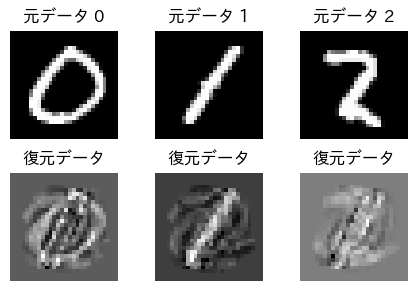

[mlp] Label a の例 -> [0, 1, 2]


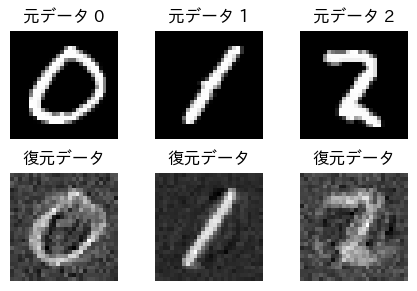

[proc] Label a の例 -> [0, 1, 2]


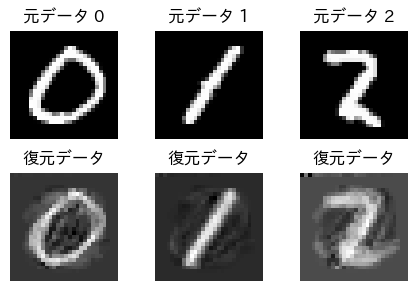

[pinv_orth] Label a の例 -> [0, 1, 2]


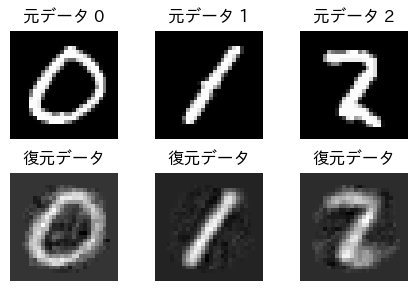

[pinv_not_orth] Label a の例 -> [0, 1, 2]


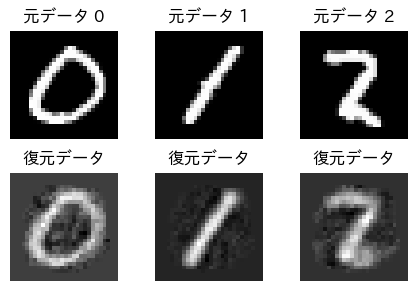

[gram] Label a の例 -> [0, 1, 2]


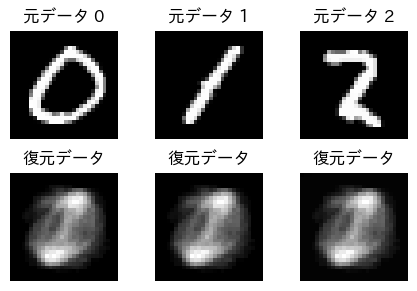

[gram_orth] Label a の例 -> [0, 1, 2]


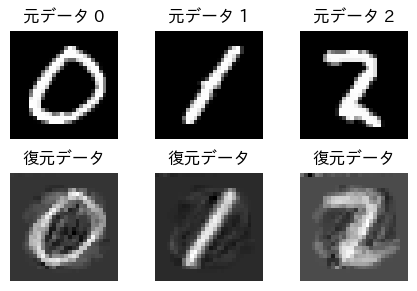

[pinv] Label not-a の例 -> [3, 4, 5, 6, 7]


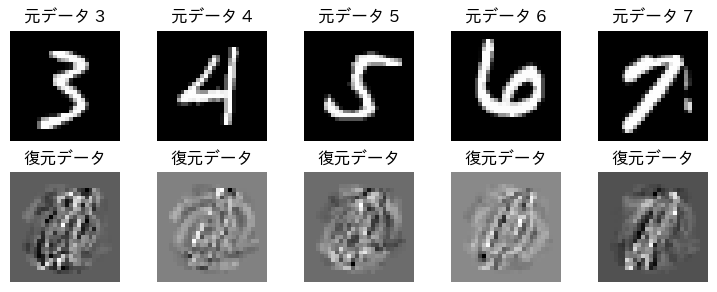

[mlp] Label not-a の例 -> [3, 4, 5, 6, 7]


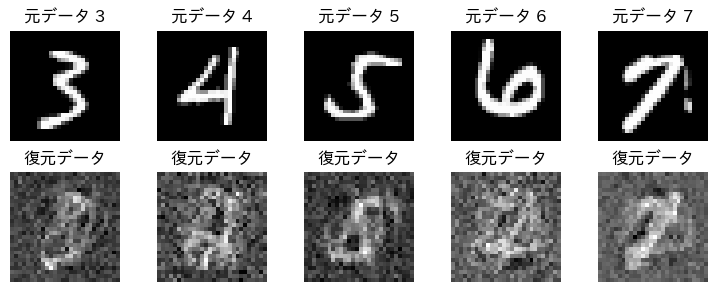

[proc] Label not-a の例 -> [3, 4, 5, 6, 7]


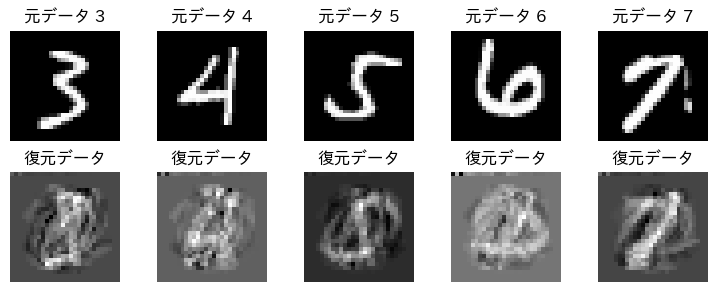

[pinv_orth] Label not-a の例 -> [3, 4, 5, 6, 7]


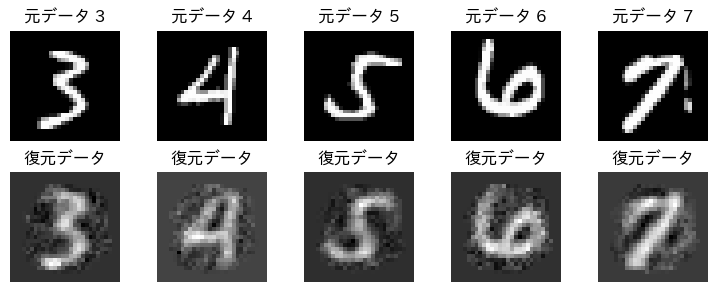

[pinv_not_orth] Label not-a の例 -> [3, 4, 5, 6, 7]


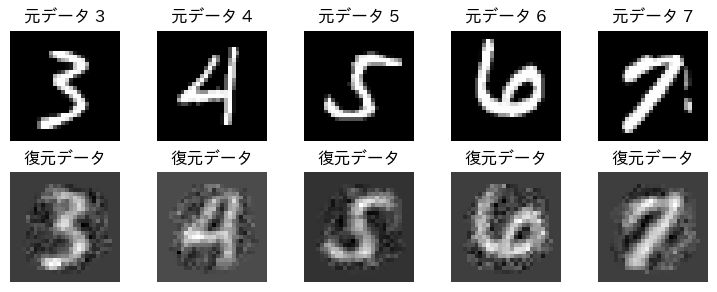

[gram] Label not-a の例 -> [3, 4, 5, 6, 7]


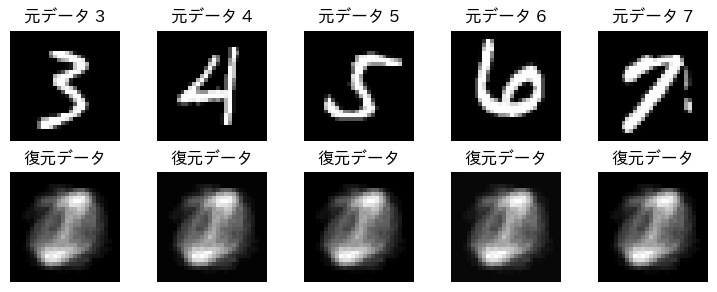

[gram_orth] Label not-a の例 -> [3, 4, 5, 6, 7]


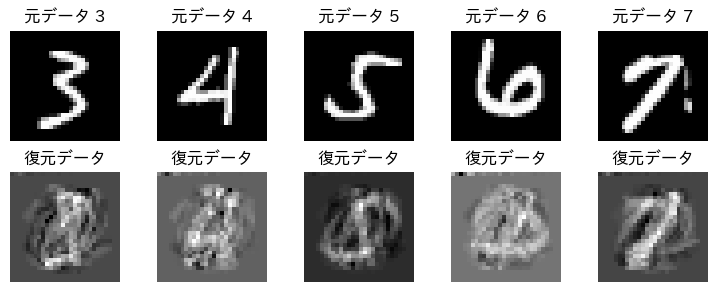

[anchor_local_leak] dataset=mnist, F_type=svd, dim=30, anchors=300, a_label=0, spill_type=local
  pseudo-inverse ACC   : all=0.3520, a=0.5608, not_a=0.2459
  MLP ACC              : all=0.3950, a=0.6944, not_a=0.2428
  Procrustes ACC       : all=0.5590, a=0.8042, not_a=0.4344
  pinv_orth ACC        : all=0.8290, a=0.9021, not_a=0.7919
  pinv_not_orth ACC    : all=0.8200, a=0.8665, not_a=0.7964
  gram ACC             : all=0.0970, a=0.0000, not_a=0.1463
  gram_orth ACC        : all=0.5390, a=0.8012, not_a=0.4057
cols 785
Index(['pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7',
       'pixel8', 'pixel9', 'pixel10'],
      dtype='object')
[label counts] user: {1: 128, 0: 110, 3: 100, 2: 99, 5: 98, 6: 97, 8: 97, 9: 96, 7: 95, 4: 80}
[label counts] anchor_pool: {1: 7749, 7: 7198, 3: 7041, 2: 6891, 9: 6862, 0: 6793, 6: 6779, 4: 6744, 8: 6728, 5: 6215}


/Users/suetake/git-repos/takano_labo/dca/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


UMAP seed: 13


/Users/suetake/git-repos/takano_labo/dca/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[pinv] Label a の例 -> [0, 1, 2]


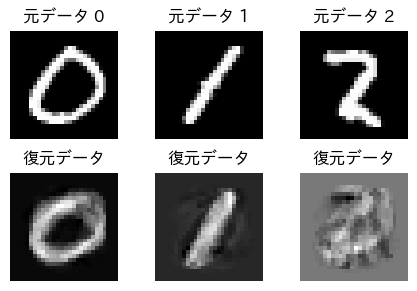

[mlp] Label a の例 -> [0, 1, 2]


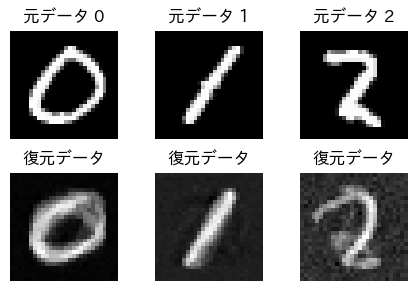

[proc] Label a の例 -> [0, 1, 2]


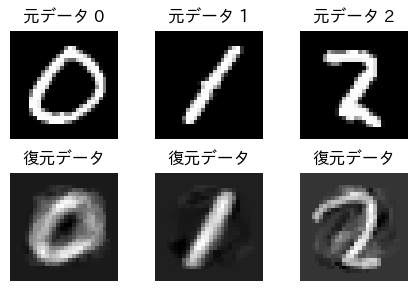

[pinv_orth] Label a の例 -> [0, 1, 2]


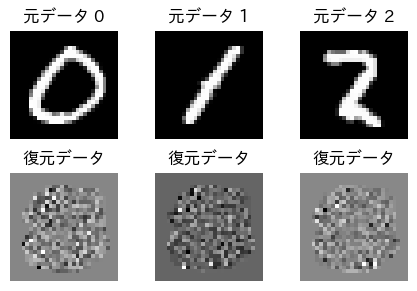

[pinv_not_orth] Label a の例 -> [0, 1, 2]


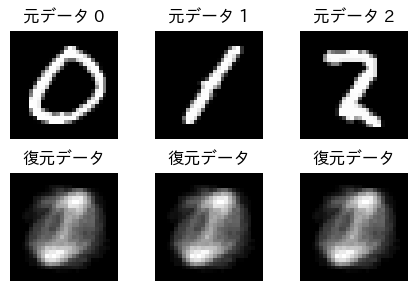

[gram] Label a の例 -> [0, 1, 2]


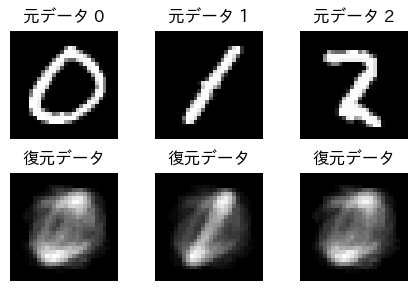

[gram_orth] Label a の例 -> [0, 1, 2]


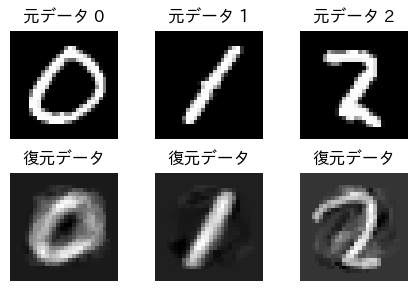

[pinv] Label not-a の例 -> [3, 4, 5, 6, 7]


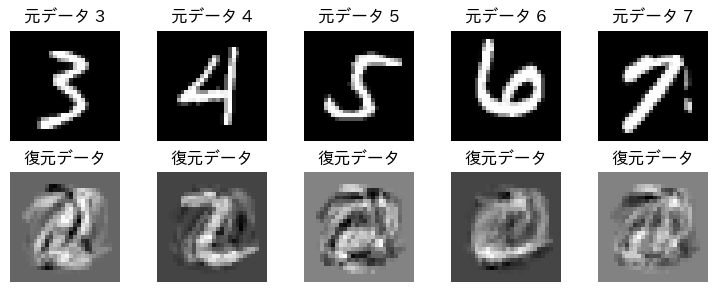

[mlp] Label not-a の例 -> [3, 4, 5, 6, 7]


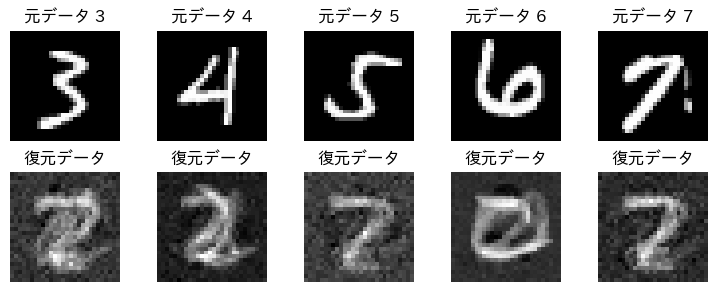

[proc] Label not-a の例 -> [3, 4, 5, 6, 7]


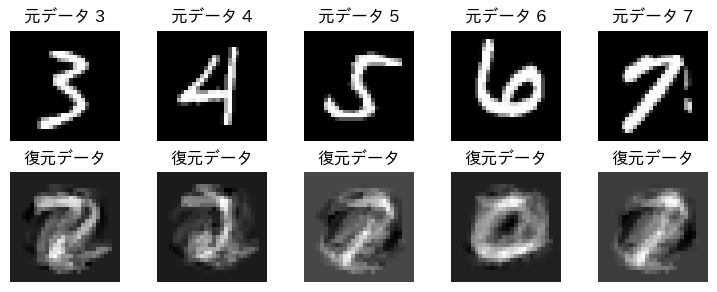

[pinv_orth] Label not-a の例 -> [3, 4, 5, 6, 7]


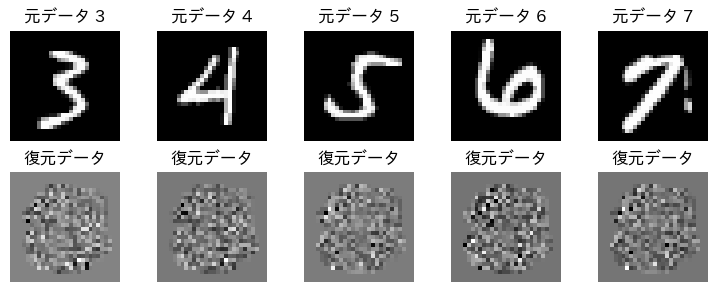

[pinv_not_orth] Label not-a の例 -> [3, 4, 5, 6, 7]


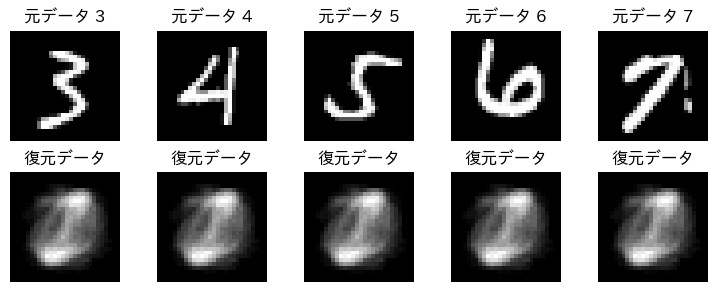

[gram] Label not-a の例 -> [3, 4, 5, 6, 7]


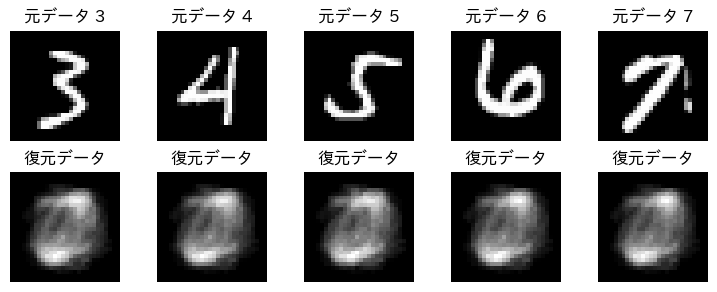

[gram_orth] Label not-a の例 -> [3, 4, 5, 6, 7]


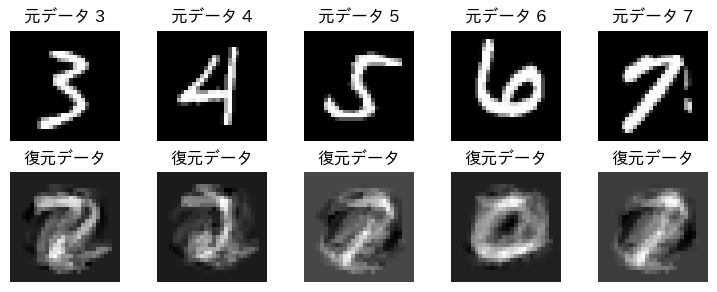

[anchor_local_leak] dataset=mnist, F_type=umap, dim=30, anchors=300, a_label=0, spill_type=local
  pseudo-inverse ACC   : all=0.2740, a=0.6231, not_a=0.0965
  MLP ACC              : all=0.3300, a=0.7418, not_a=0.1207
  Procrustes ACC       : all=0.3900, a=0.9169, not_a=0.1222
  pinv_orth ACC        : all=0.1040, a=0.0356, not_a=0.1388
  pinv_not_orth ACC    : all=0.0970, a=0.0000, not_a=0.1463
  gram ACC             : all=0.1210, a=0.0712, not_a=0.1463
  gram_orth ACC        : all=0.3860, a=0.8754, not_a=0.1373


In [12]:
from config.config import Config

base_config_dict = {
    "name": ["tutorial_mnist"],
    "dataset": [
    #"fashion_mnist",
    "mnist",
    #"mnist_1248",
    #"mice",
    #"statlog",
    #"qsar",
    #"digits",
    #"breast_cancer",
    #"adult",
    #"glass", 
    #"seeds", 
    #"letter_recognition",
    #"wine_quality",
    #"har",
    #"cifar10",
    #'3D_gaussian_clusters',
    #"concentric_three_circles",
    #"iris",
    #"ecoli",
    #"vowel"
    #"medmnist_3",
    #"medmnist_5"
],
    "spill_type": ["local"], # "local", "even", 
    #"spill_label": [[0, 1, 2]],
    "y_name": ["target"],
    "num_institution_user": [1000],
    "data_distribution": ["even"],
    "anchor_method": ["smote"], # "smote"
    "num_anchor_data": [300],
    "spill_label": [[0,1,2]],
    "dim_intermediate": [30],
    "visualize_not_a_labels": [[3,4,5,6,7]],
    #"spill_num": [300],
    "F_type": ["svd", "umap"], #   "ae", "kernel_pca_self_tuning", "umap"
    "recon_centering": [True],
    "inter_normalization": [False],
    "preprocess":[False],
    "smote_ratio": [1],
    "gamma_ratio": [1.0],
    "public_anchor_num": [100],
    "use_public_anchor": ["spill_label"],
    #"use_public_anchor":[False],
    "seed":[13],
    "visualize_rec": [True],
    #"visualize_method_list": [["pinv", "pinv_not_orth", "gram", "gram_orth"]],
    "noise_level": [0.0],
}


df_results = run_anchor_local_leak_grid(base_config_dict)
df_results
# 適当な CSV 出力
df_results.to_csv("anchor_local_leak_results.csv", index=False)


cols 785
Index(['pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7',
       'pixel8', 'pixel9', 'pixel10'],
      dtype='object')
[label counts] user: {9: 122, 5: 114, 7: 106, 0: 104, 1: 100, 2: 99, 6: 92, 3: 90, 8: 90, 4: 83}
[label counts] anchor_pool: {1: 7777, 7: 7187, 3: 7051, 2: 6891, 9: 6836, 0: 6799, 6: 6784, 4: 6741, 8: 6735, 5: 6199}
[pinv] Label a の例 -> [0, 1, 2]


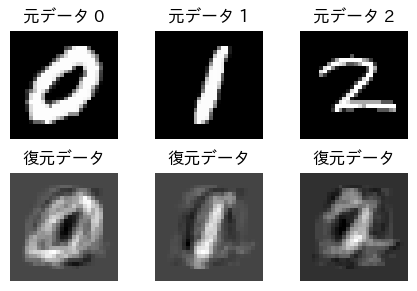

[mlp] Label a の例 -> [0, 1, 2]


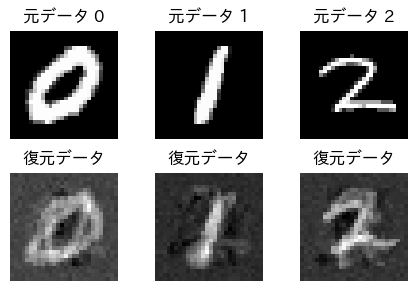

[proc] Label a の例 -> [0, 1, 2]


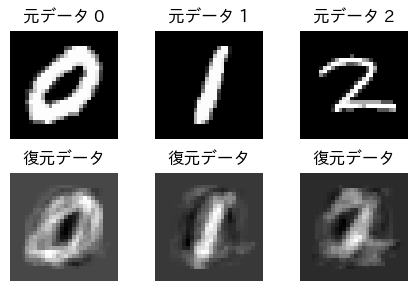

[pinv_orth] Label a の例 -> [0, 1, 2]


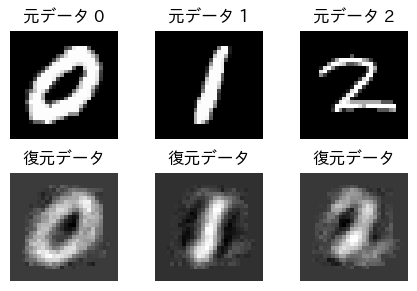

[pinv_not_orth] Label a の例 -> [0, 1, 2]


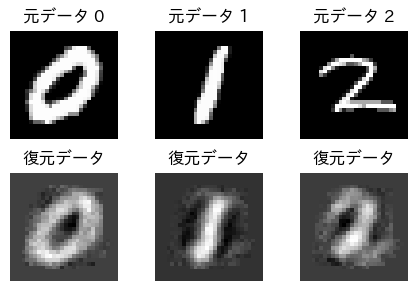

[gram] Label a の例 -> [0, 1, 2]


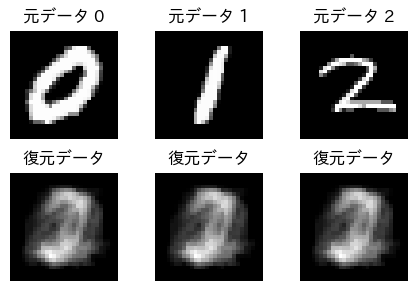

[gram_orth] Label a の例 -> [0, 1, 2]


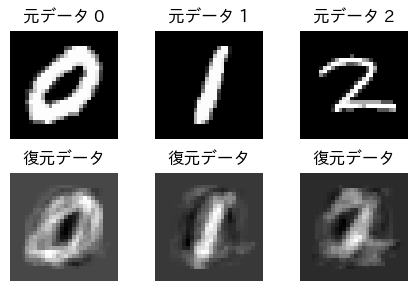

[pinv] Label not-a の例 -> [3, 4, 5, 6, 7, 8, 9]


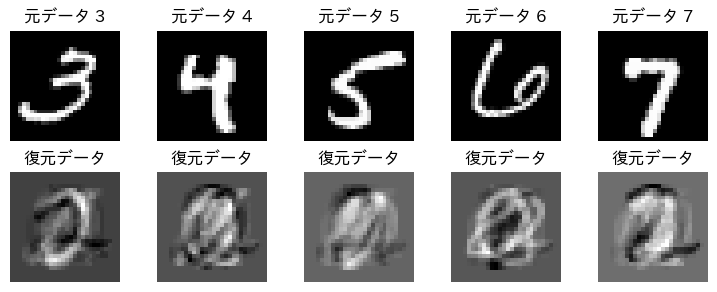

[mlp] Label not-a の例 -> [3, 4, 5, 6, 7, 8, 9]


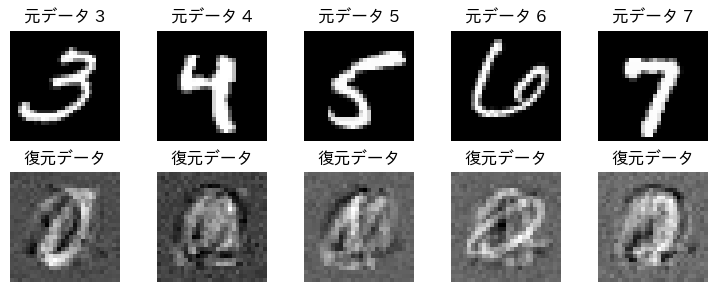

[proc] Label not-a の例 -> [3, 4, 5, 6, 7, 8, 9]


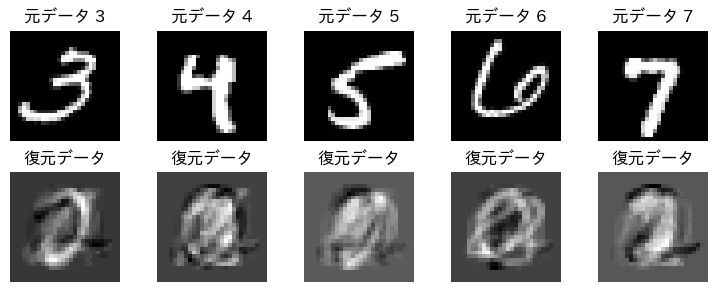

[pinv_orth] Label not-a の例 -> [3, 4, 5, 6, 7, 8, 9]


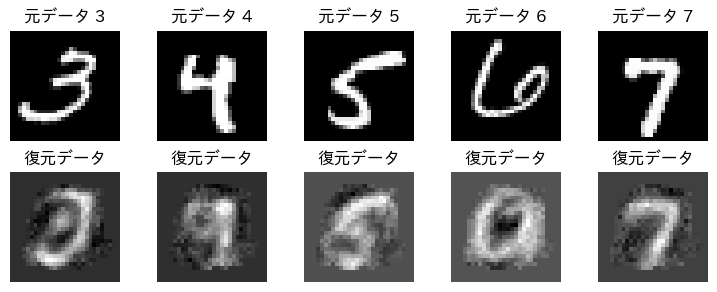

[pinv_not_orth] Label not-a の例 -> [3, 4, 5, 6, 7, 8, 9]


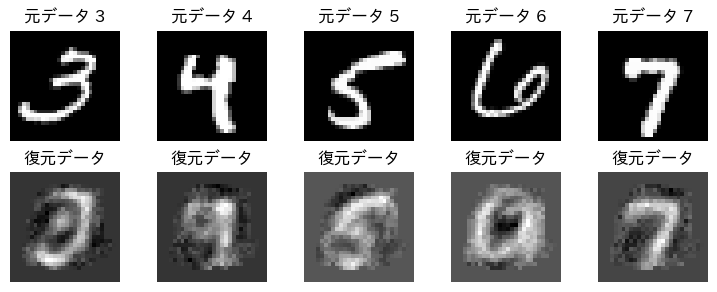

[gram] Label not-a の例 -> [3, 4, 5, 6, 7, 8, 9]


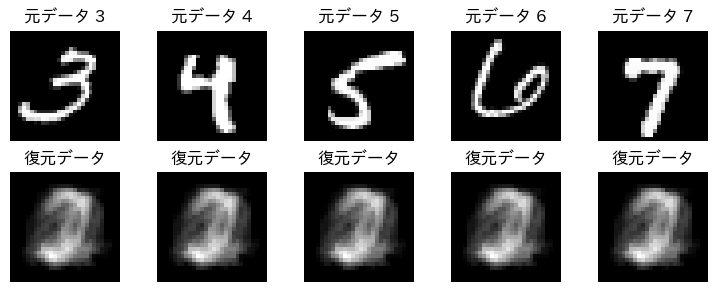

[gram_orth] Label not-a の例 -> [3, 4, 5, 6, 7, 8, 9]


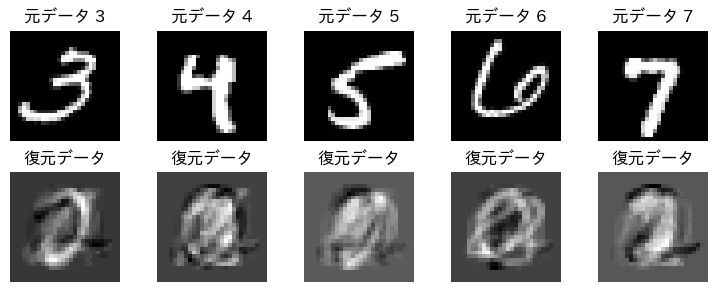

[anchor_local_leak] dataset=mnist, F_type=svd, dim=10, anchors=300, a_label=0, spill_type=local
  pseudo-inverse ACC   : all=0.4640, a=0.6766, not_a=0.3716
  MLP ACC              : all=0.4010, a=0.7690, not_a=0.2410
  Procrustes ACC       : all=0.3570, a=0.5809, not_a=0.2597
  pinv_orth ACC        : all=0.4790, a=0.6073, not_a=0.4232
  pinv_not_orth ACC    : all=0.5080, a=0.6007, not_a=0.4677
  gram ACC             : all=0.1010, a=0.2013, not_a=0.0574
  gram_orth ACC        : all=0.3460, a=0.6700, not_a=0.2052
cols 785
Index(['pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7',
       'pixel8', 'pixel9', 'pixel10'],
      dtype='object')
[label counts] user: {9: 122, 5: 114, 7: 106, 0: 104, 1: 100, 2: 99, 6: 92, 3: 90, 8: 90, 4: 83}
[label counts] anchor_pool: {1: 7777, 7: 7187, 3: 7051, 2: 6891, 9: 6836, 0: 6799, 6: 6784, 4: 6741, 8: 6735, 5: 6199}
UMAP seed: 4


/Users/suetake/git-repos/takano_labo/dca/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[pinv] Label a の例 -> [0, 1, 2]


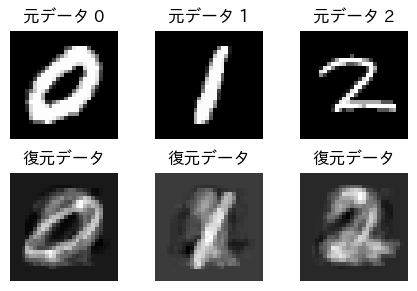

[mlp] Label a の例 -> [0, 1, 2]


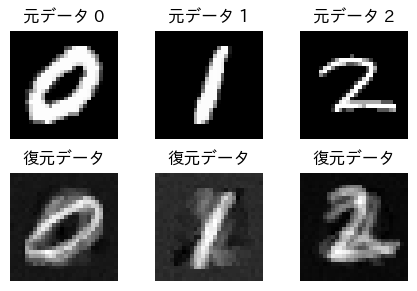

[proc] Label a の例 -> [0, 1, 2]


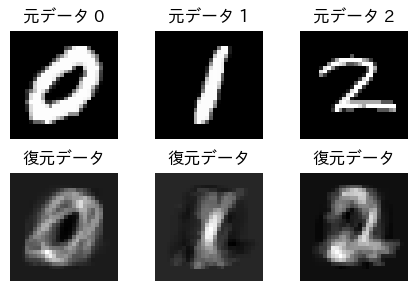

[pinv_orth] Label a の例 -> [0, 1, 2]


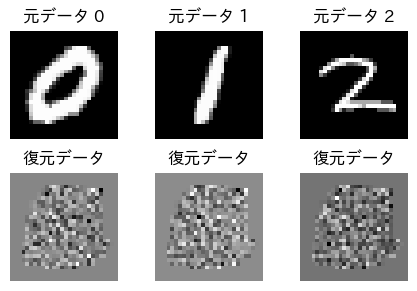

[pinv_not_orth] Label a の例 -> [0, 1, 2]


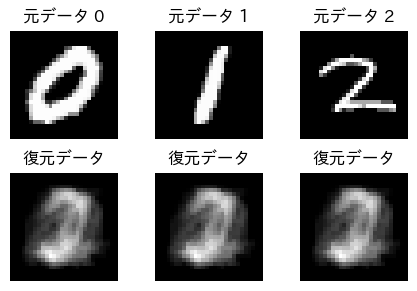

[gram] Label a の例 -> [0, 1, 2]


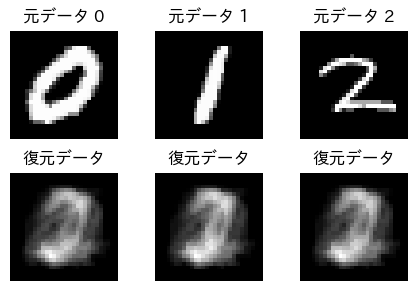

[gram_orth] Label a の例 -> [0, 1, 2]


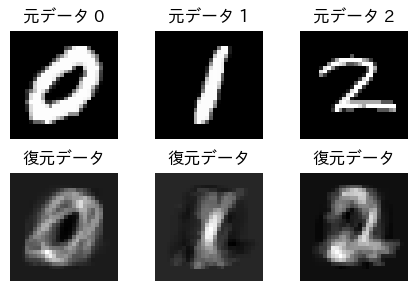

[pinv] Label not-a の例 -> [3, 4, 5, 6, 7, 8, 9]


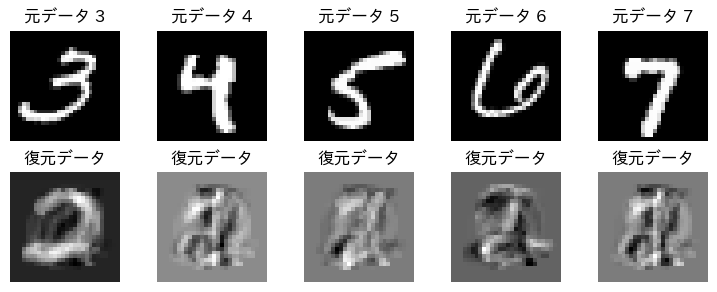

[mlp] Label not-a の例 -> [3, 4, 5, 6, 7, 8, 9]


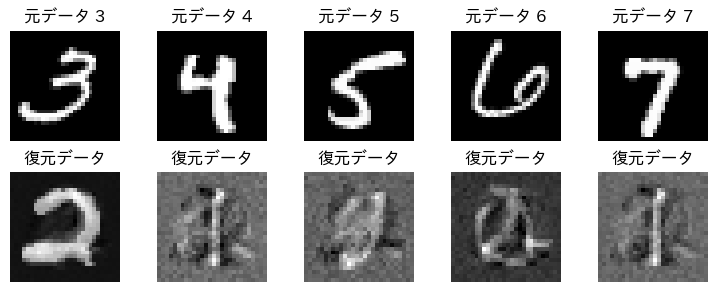

[proc] Label not-a の例 -> [3, 4, 5, 6, 7, 8, 9]


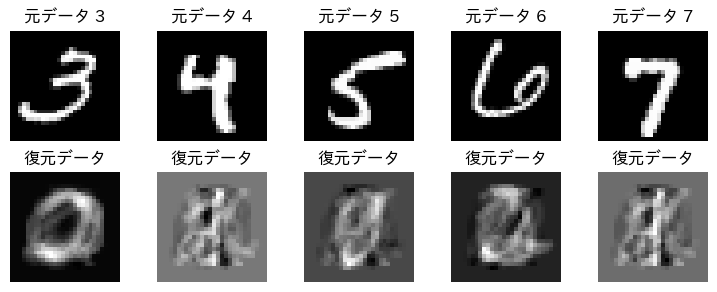

[pinv_orth] Label not-a の例 -> [3, 4, 5, 6, 7, 8, 9]


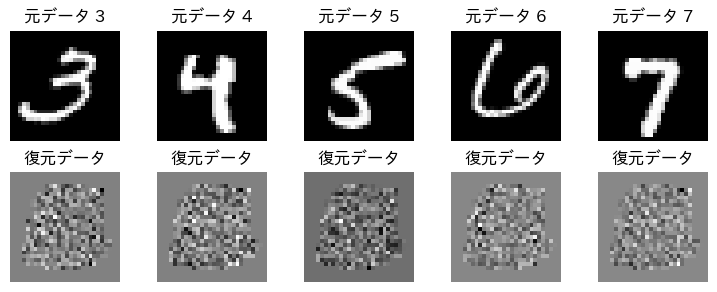

[pinv_not_orth] Label not-a の例 -> [3, 4, 5, 6, 7, 8, 9]


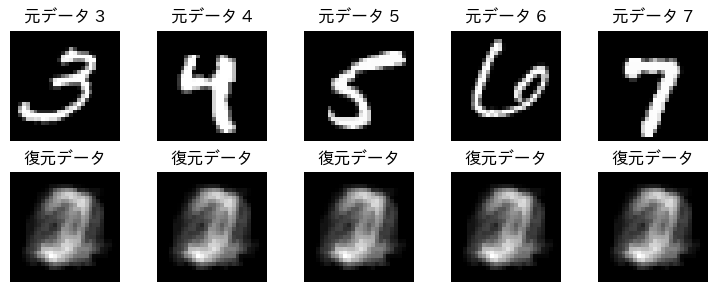

[gram] Label not-a の例 -> [3, 4, 5, 6, 7, 8, 9]


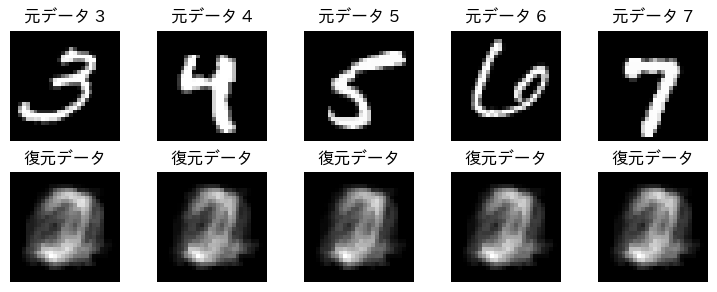

[gram_orth] Label not-a の例 -> [3, 4, 5, 6, 7, 8, 9]


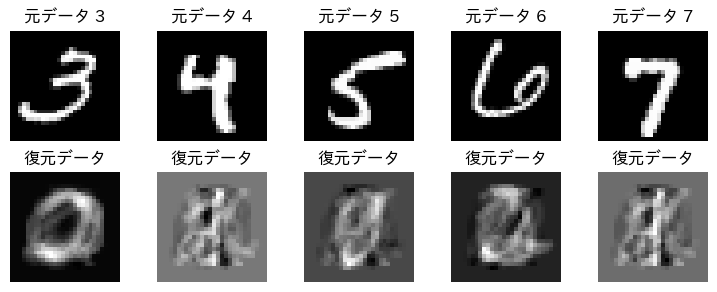

[anchor_local_leak] dataset=mnist, F_type=umap, dim=10, anchors=300, a_label=0, spill_type=local
  pseudo-inverse ACC   : all=0.2730, a=0.6568, not_a=0.1062
  MLP ACC              : all=0.2760, a=0.6931, not_a=0.0947
  Procrustes ACC       : all=0.3230, a=0.7360, not_a=0.1435
  pinv_orth ACC        : all=0.0620, a=0.0429, not_a=0.0703
  pinv_not_orth ACC    : all=0.0900, a=0.0000, not_a=0.1291
  gram ACC             : all=0.1190, a=0.2838, not_a=0.0473
  gram_orth ACC        : all=0.3590, a=0.7822, not_a=0.1750


In [13]:
from config.config import Config

base_config_dict = {
    "name": ["tutorial_mnist"],
    "dataset": [
    #"fashion_mnist",
    "mnist",
    #"mnist_1248",
    #"mice",
    #"statlog",
    #"qsar",
    #"digits",
    #"breast_cancer",
    #"adult",
    #"glass", 
    #"seeds", 
    #"letter_recognition",
    #"wine_quality",
    #"har",
    #"cifar10",
    #'3D_gaussian_clusters',
    #"concentric_three_circles",
    #"iris",
    #"ecoli",
    #"vowel"
    #"medmnist_3",
    #"medmnist_5"
],
    "spill_type": ["local"], # "local", "even", 
    #"spill_label": [[0, 1, 2]],
    "y_name": ["target"],
    "num_institution_user": [1000],
    "data_distribution": ["even"],
    "anchor_method": ["smote"], # "smote"
    "num_anchor_data": [300],
    "spill_label": [[0,1,2]],
    "dim_intermediate": [10],
    "visualize_not_a_labels": [[3,4,5,6,7,8,9]],
    #"spill_num": [300],
    "F_type": ["svd", "umap"], #   "ae", "kernel_pca_self_tuning", "umap"
    "recon_centering": [True],
    "inter_normalization": [False],
    "preprocess":[False],
    "smote_ratio": [1],
    "gamma_ratio": [1.0],
    "public_anchor_num": [100],
    "use_public_anchor": ["spill_label"],
    #"use_public_anchor":[False],
    "seed":[4],
    "visualize_rec": [True],
    #"visualize_method_list": [["pinv", "pinv_not_orth", "gram", "gram_orth"]],
    "noise_level": [0.0],
}


df_results = run_anchor_local_leak_grid(base_config_dict)
df_results
# 適当な CSV 出力
df_results.to_csv("anchor_local_leak_results.csv", index=False)


cols 785
Index(['pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7',
       'pixel8', 'pixel9', 'pixel10'],
      dtype='object')
[label counts] user: {8: 116, 9: 107, 4: 106, 3: 105, 1: 104, 0: 103, 6: 101, 7: 97, 2: 89, 5: 72}
[label counts] anchor_pool: {1: 7773, 7: 7196, 3: 7036, 2: 6901, 9: 6851, 0: 6800, 6: 6775, 4: 6718, 8: 6709, 5: 6241}
[pinv] Label a の例 -> [0, 1, 2]


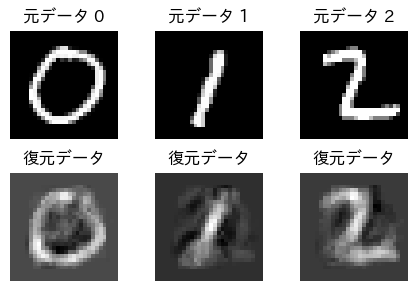

[mlp] Label a の例 -> [0, 1, 2]


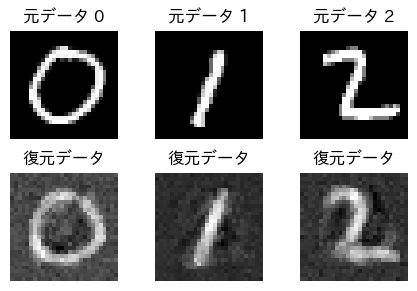

[proc] Label a の例 -> [0, 1, 2]


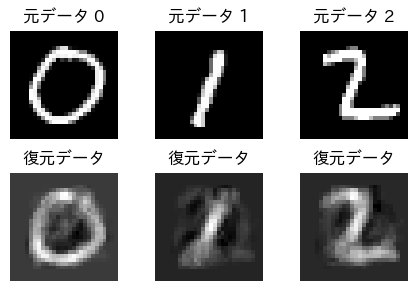

[pinv_orth] Label a の例 -> [0, 1, 2]


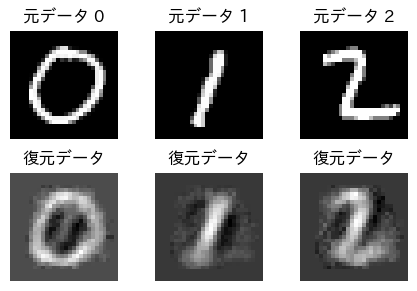

[pinv_not_orth] Label a の例 -> [0, 1, 2]


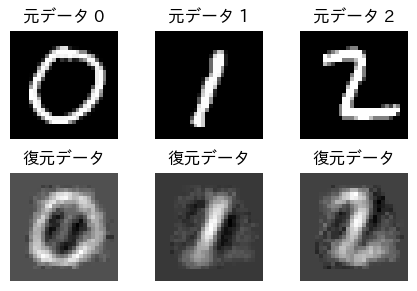

[gram] Label a の例 -> [0, 1, 2]


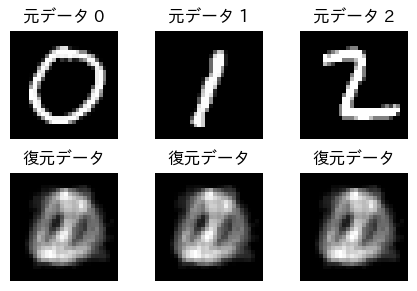

[gram_orth] Label a の例 -> [0, 1, 2]


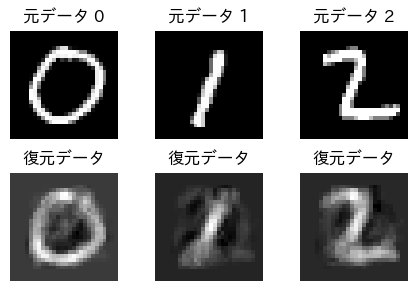

[pinv] Label not-a の例 -> [3, 4, 5, 6, 7, 8, 9]


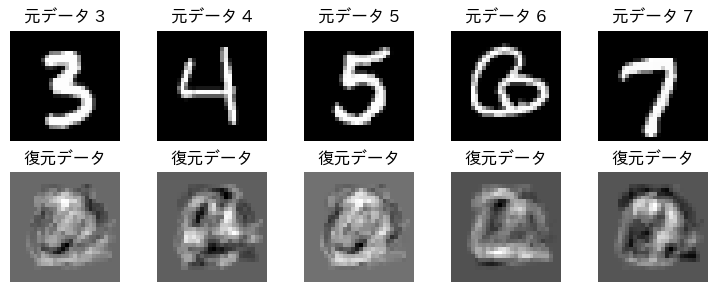

[mlp] Label not-a の例 -> [3, 4, 5, 6, 7, 8, 9]


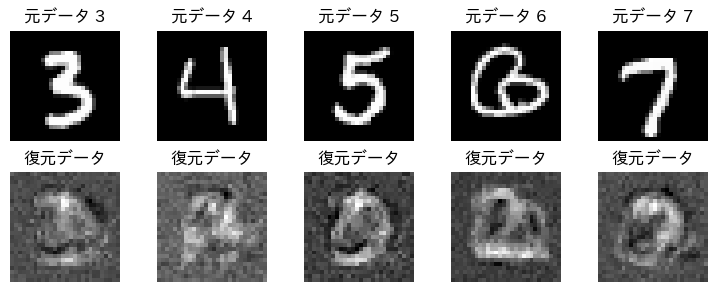

[proc] Label not-a の例 -> [3, 4, 5, 6, 7, 8, 9]


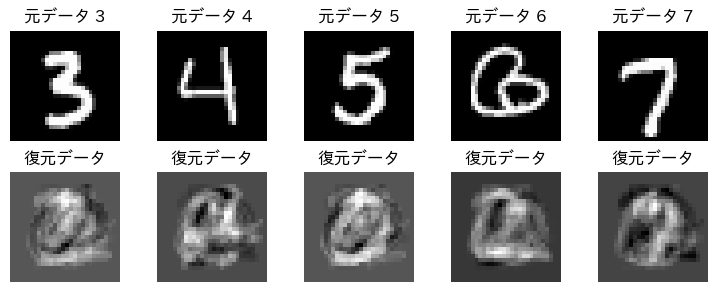

[pinv_orth] Label not-a の例 -> [3, 4, 5, 6, 7, 8, 9]


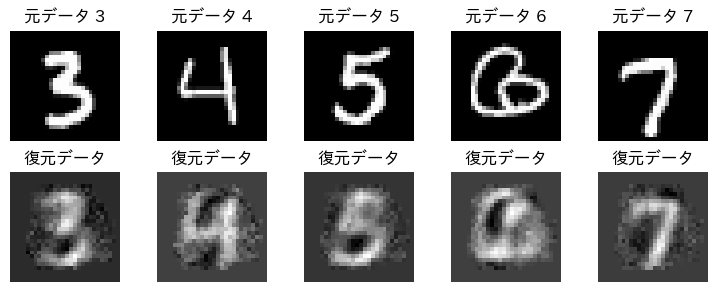

[pinv_not_orth] Label not-a の例 -> [3, 4, 5, 6, 7, 8, 9]


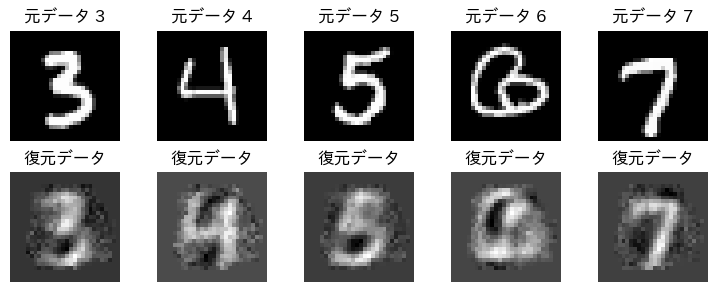

[gram] Label not-a の例 -> [3, 4, 5, 6, 7, 8, 9]


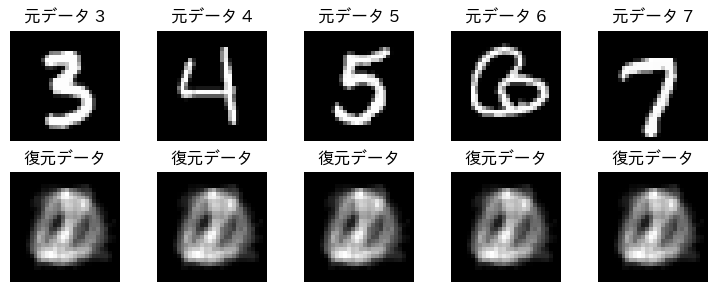

[gram_orth] Label not-a の例 -> [3, 4, 5, 6, 7, 8, 9]


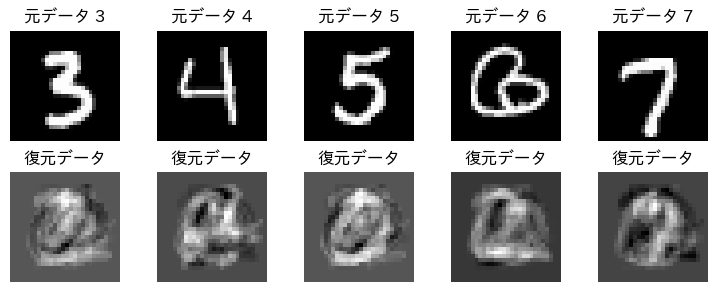

[anchor_local_leak] dataset=mnist, F_type=svd, dim=10, anchors=300, a_label=0, spill_type=local
  pseudo-inverse ACC   : all=0.5000, a=0.6115, not_a=0.4531
  MLP ACC              : all=0.4990, a=0.7601, not_a=0.3892
  Procrustes ACC       : all=0.4150, a=0.5541, not_a=0.3565
  pinv_orth ACC        : all=0.5140, a=0.5777, not_a=0.4872
  pinv_not_orth ACC    : all=0.5150, a=0.4764, not_a=0.5312
  gram ACC             : all=0.1010, a=0.0000, not_a=0.1435
  gram_orth ACC        : all=0.3900, a=0.5439, not_a=0.3253
cols 785
Index(['pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7',
       'pixel8', 'pixel9', 'pixel10'],
      dtype='object')
[label counts] user: {3: 114, 1: 108, 0: 107, 8: 102, 4: 102, 2: 102, 6: 98, 9: 96, 7: 93, 5: 78}
[label counts] anchor_pool: {1: 7769, 7: 7200, 3: 7027, 2: 6888, 9: 6862, 0: 6796, 6: 6778, 8: 6723, 4: 6722, 5: 6235}
[pinv] Label a の例 -> [0, 1, 2]


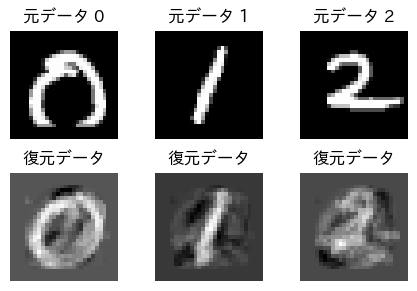

[mlp] Label a の例 -> [0, 1, 2]


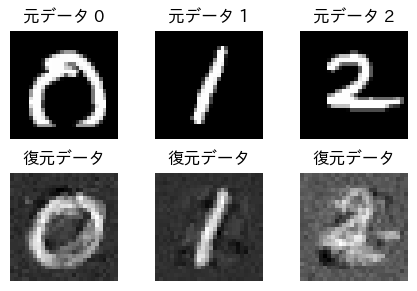

[proc] Label a の例 -> [0, 1, 2]


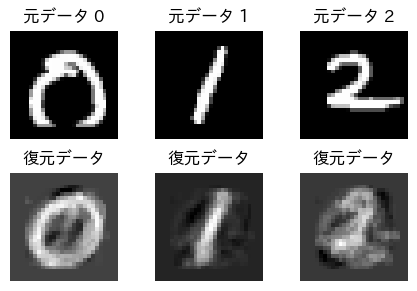

[pinv_orth] Label a の例 -> [0, 1, 2]


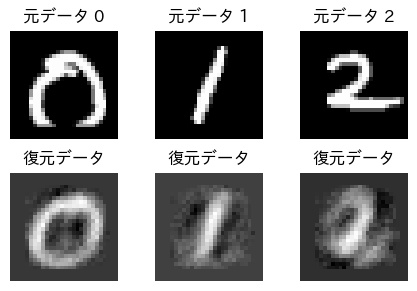

[pinv_not_orth] Label a の例 -> [0, 1, 2]


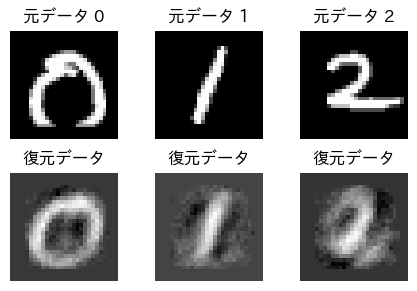

[gram] Label a の例 -> [0, 1, 2]


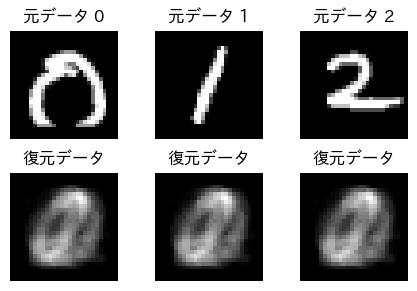

[gram_orth] Label a の例 -> [0, 1, 2]


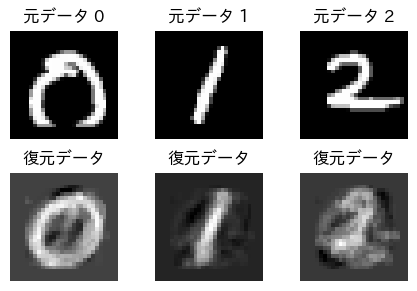

[pinv] Label not-a の例 -> [3, 4, 5, 6, 7, 8, 9]


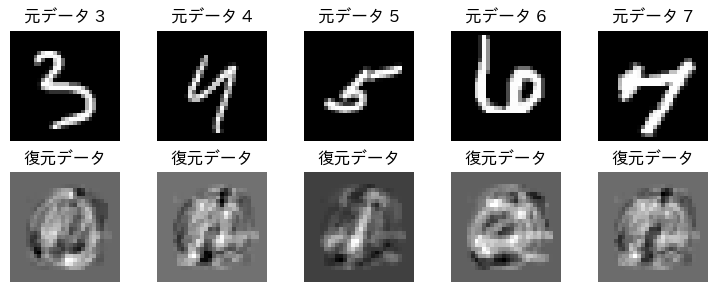

[mlp] Label not-a の例 -> [3, 4, 5, 6, 7, 8, 9]


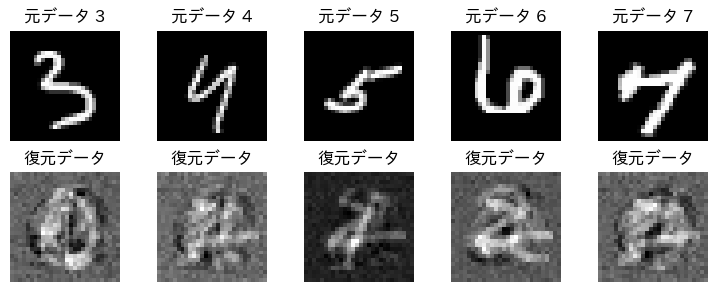

[proc] Label not-a の例 -> [3, 4, 5, 6, 7, 8, 9]


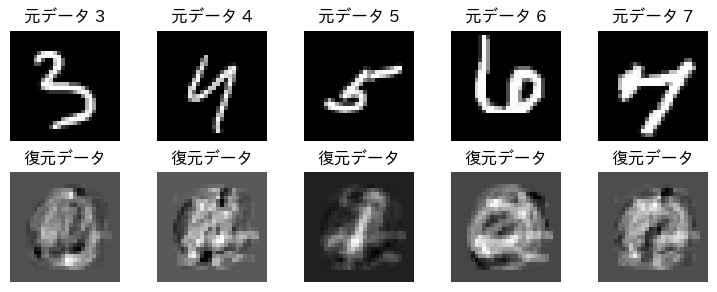

[pinv_orth] Label not-a の例 -> [3, 4, 5, 6, 7, 8, 9]


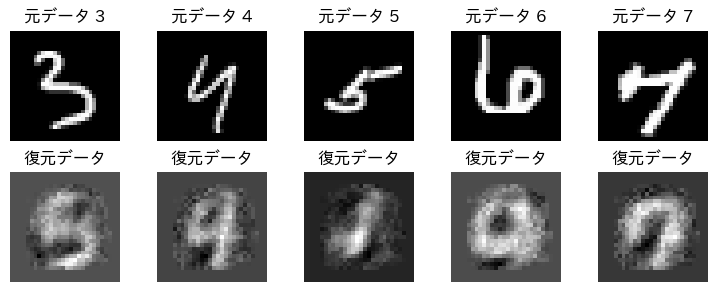

[pinv_not_orth] Label not-a の例 -> [3, 4, 5, 6, 7, 8, 9]


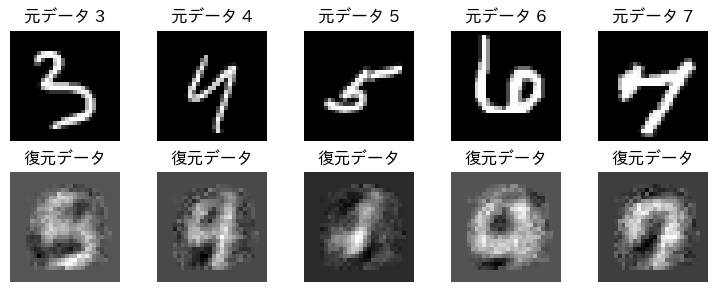

[gram] Label not-a の例 -> [3, 4, 5, 6, 7, 8, 9]


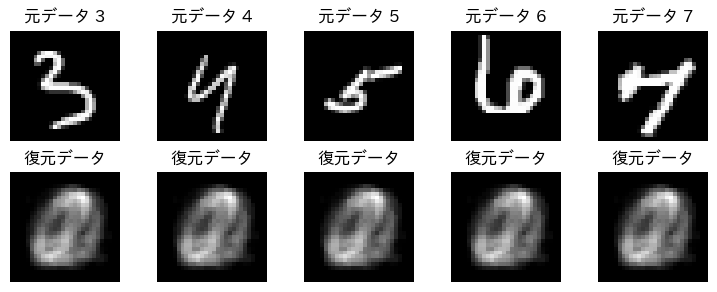

[gram_orth] Label not-a の例 -> [3, 4, 5, 6, 7, 8, 9]


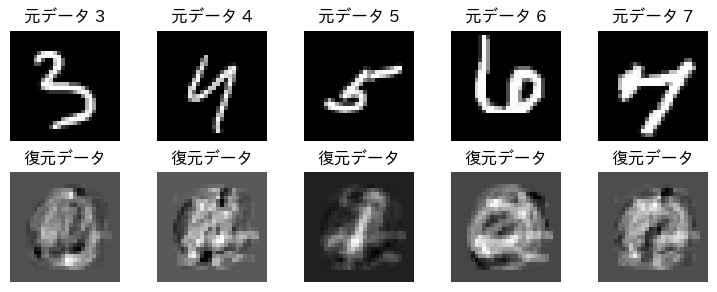

[anchor_local_leak] dataset=mnist, F_type=svd, dim=10, anchors=300, a_label=0, spill_type=local
  pseudo-inverse ACC   : all=0.5040, a=0.7256, not_a=0.4012
  MLP ACC              : all=0.4880, a=0.7666, not_a=0.3587
  Procrustes ACC       : all=0.4490, a=0.6751, not_a=0.3441
  pinv_orth ACC        : all=0.5460, a=0.6151, not_a=0.5139
  pinv_not_orth ACC    : all=0.6010, a=0.5552, not_a=0.6223
  gram ACC             : all=0.1070, a=0.3375, not_a=0.0000
  gram_orth ACC        : all=0.4470, a=0.7129, not_a=0.3236
cols 785
Index(['pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7',
       'pixel8', 'pixel9', 'pixel10'],
      dtype='object')
[label counts] user: {8: 116, 9: 107, 4: 106, 3: 105, 1: 104, 0: 103, 6: 101, 7: 97, 2: 89, 5: 72}
[label counts] anchor_pool: {1: 7773, 7: 7196, 3: 7036, 2: 6901, 9: 6851, 0: 6800, 6: 6775, 4: 6718, 8: 6709, 5: 6241}
UMAP seed: 0


/Users/suetake/git-repos/takano_labo/dca/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[pinv] Label a の例 -> [0, 1, 2]


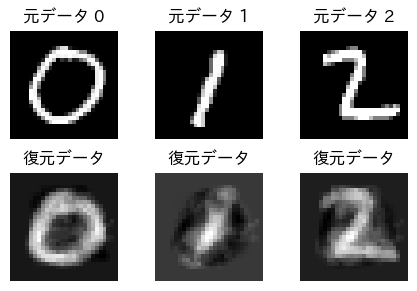

[mlp] Label a の例 -> [0, 1, 2]


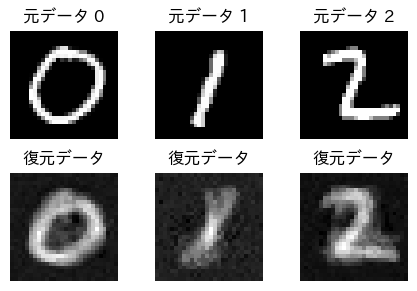

[proc] Label a の例 -> [0, 1, 2]


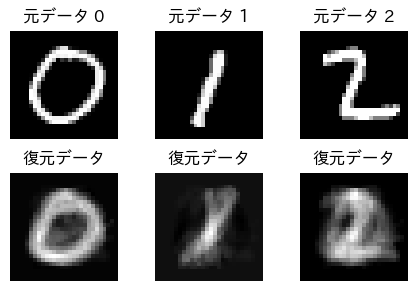

[pinv_orth] Label a の例 -> [0, 1, 2]


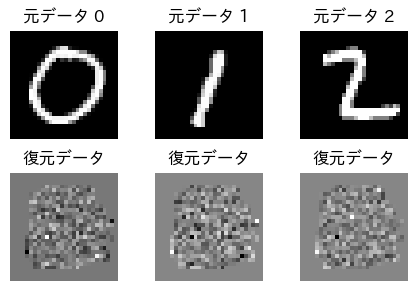

[pinv_not_orth] Label a の例 -> [0, 1, 2]


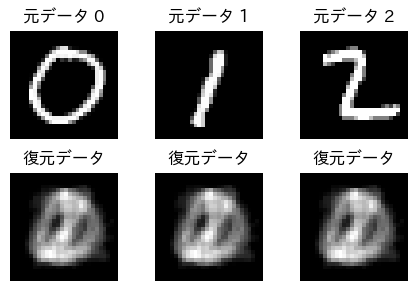

[gram] Label a の例 -> [0, 1, 2]


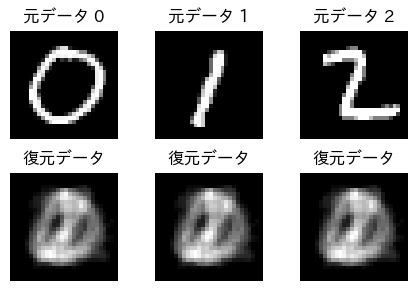

[gram_orth] Label a の例 -> [0, 1, 2]


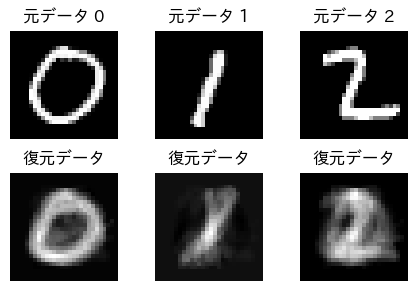

[pinv] Label not-a の例 -> [3, 4, 5, 6, 7, 8, 9]


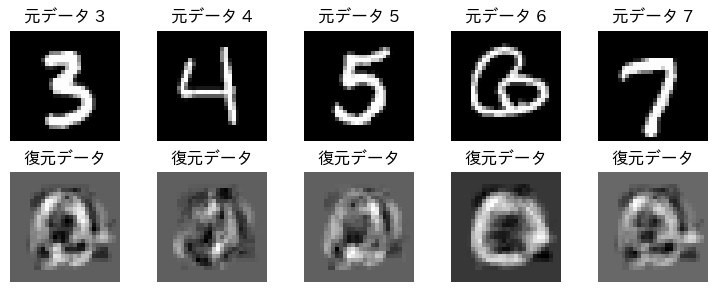

[mlp] Label not-a の例 -> [3, 4, 5, 6, 7, 8, 9]


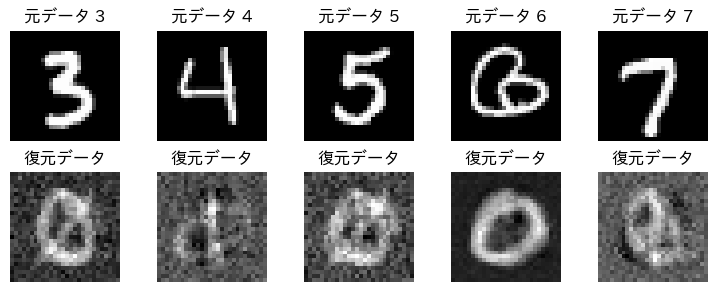

[proc] Label not-a の例 -> [3, 4, 5, 6, 7, 8, 9]


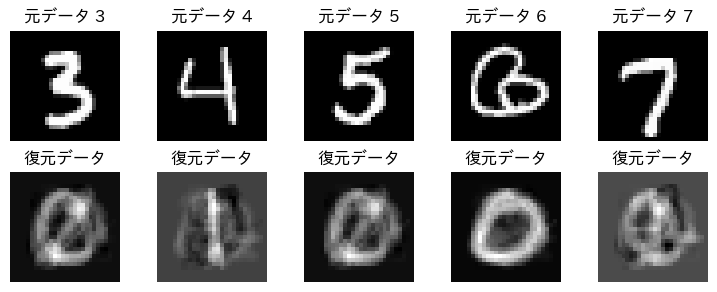

[pinv_orth] Label not-a の例 -> [3, 4, 5, 6, 7, 8, 9]


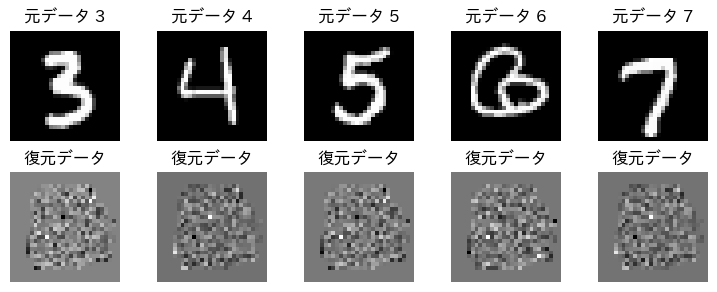

[pinv_not_orth] Label not-a の例 -> [3, 4, 5, 6, 7, 8, 9]


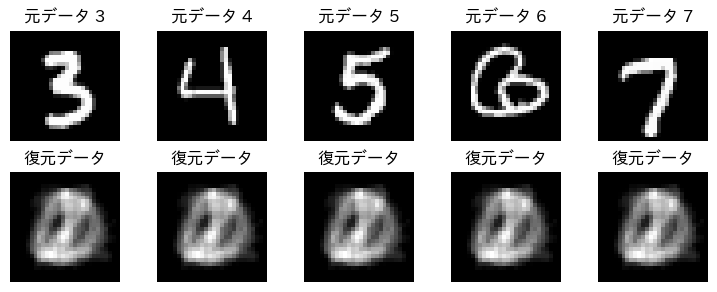

[gram] Label not-a の例 -> [3, 4, 5, 6, 7, 8, 9]


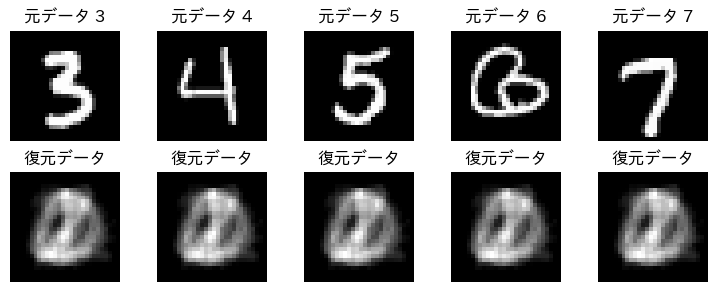

[gram_orth] Label not-a の例 -> [3, 4, 5, 6, 7, 8, 9]


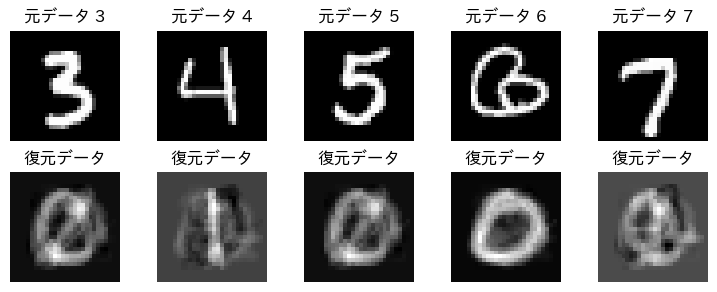

[anchor_local_leak] dataset=mnist, F_type=umap, dim=10, anchors=300, a_label=0, spill_type=local
  pseudo-inverse ACC   : all=0.2110, a=0.4899, not_a=0.0938
  MLP ACC              : all=0.1960, a=0.5270, not_a=0.0568
  Procrustes ACC       : all=0.1660, a=0.1081, not_a=0.1903
  pinv_orth ACC        : all=0.0540, a=0.0574, not_a=0.0526
  pinv_not_orth ACC    : all=0.1010, a=0.0000, not_a=0.1435
  gram ACC             : all=0.1000, a=0.0000, not_a=0.1420
  gram_orth ACC        : all=0.1430, a=0.0709, not_a=0.1733
cols 785
Index(['pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7',
       'pixel8', 'pixel9', 'pixel10'],
      dtype='object')
[label counts] user: {3: 114, 1: 108, 0: 107, 8: 102, 4: 102, 2: 102, 6: 98, 9: 96, 7: 93, 5: 78}
[label counts] anchor_pool: {1: 7769, 7: 7200, 3: 7027, 2: 6888, 9: 6862, 0: 6796, 6: 6778, 8: 6723, 4: 6722, 5: 6235}
UMAP seed: 1


/Users/suetake/git-repos/takano_labo/dca/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[pinv] Label a の例 -> [0, 1, 2]


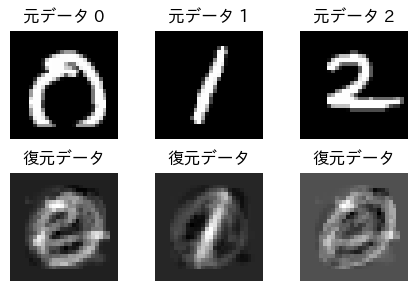

[mlp] Label a の例 -> [0, 1, 2]


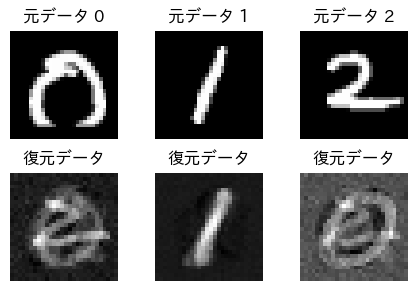

[proc] Label a の例 -> [0, 1, 2]


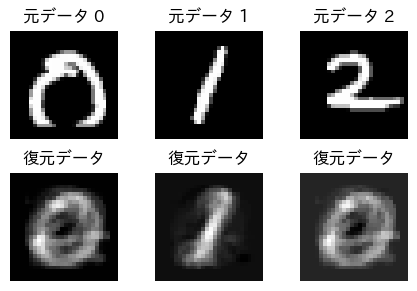

[pinv_orth] Label a の例 -> [0, 1, 2]


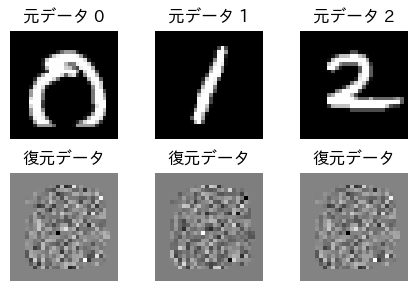

[pinv_not_orth] Label a の例 -> [0, 1, 2]


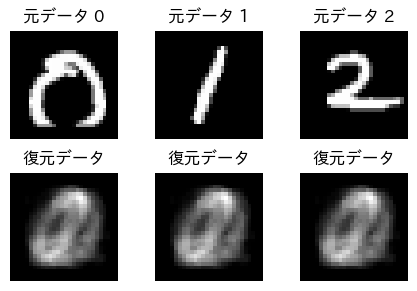

[gram] Label a の例 -> [0, 1, 2]


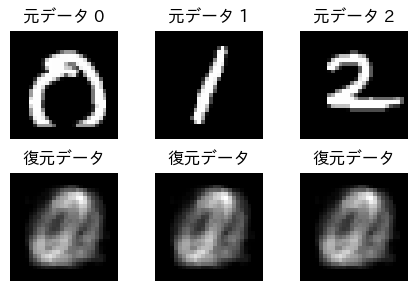

[gram_orth] Label a の例 -> [0, 1, 2]


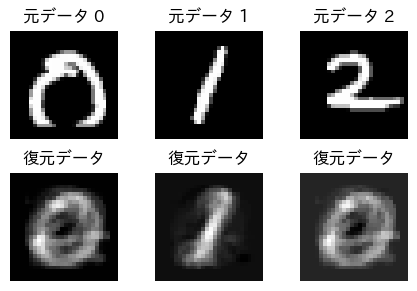

[pinv] Label not-a の例 -> [3, 4, 5, 6, 7, 8, 9]


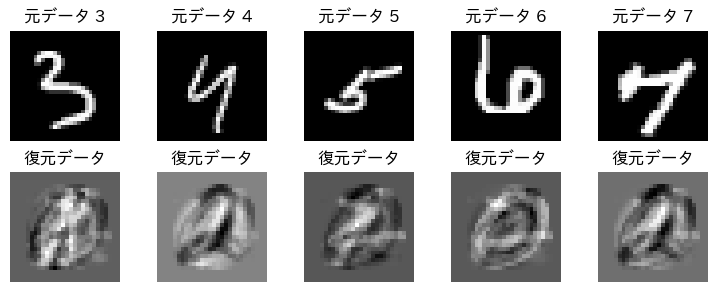

[mlp] Label not-a の例 -> [3, 4, 5, 6, 7, 8, 9]


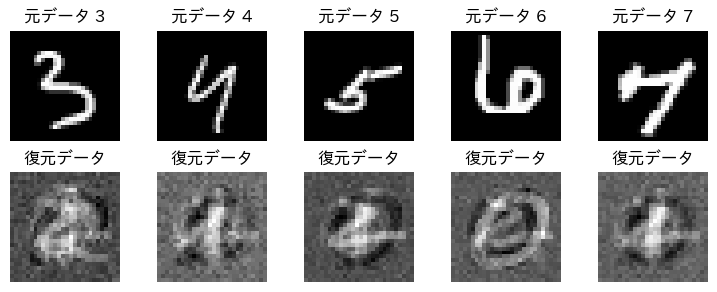

[proc] Label not-a の例 -> [3, 4, 5, 6, 7, 8, 9]


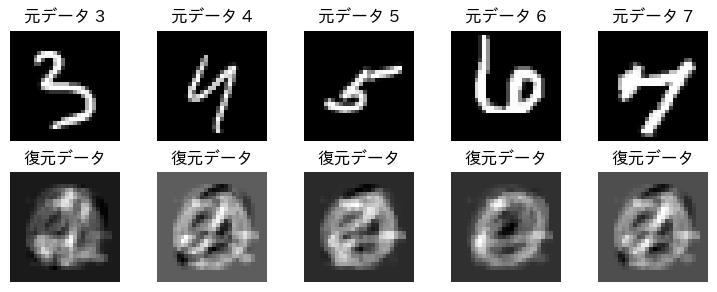

[pinv_orth] Label not-a の例 -> [3, 4, 5, 6, 7, 8, 9]


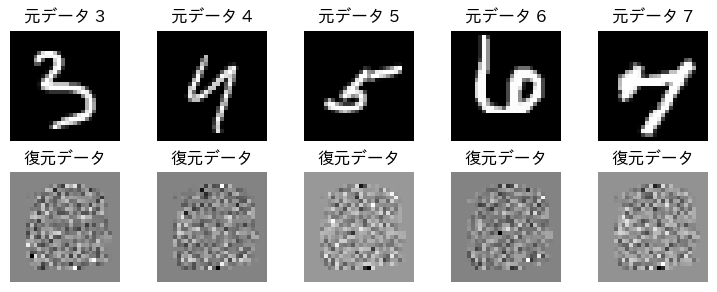

[pinv_not_orth] Label not-a の例 -> [3, 4, 5, 6, 7, 8, 9]


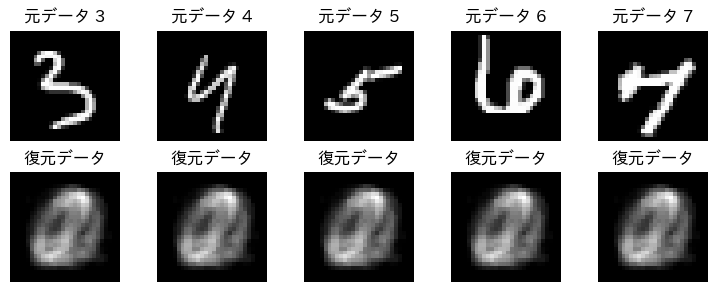

[gram] Label not-a の例 -> [3, 4, 5, 6, 7, 8, 9]


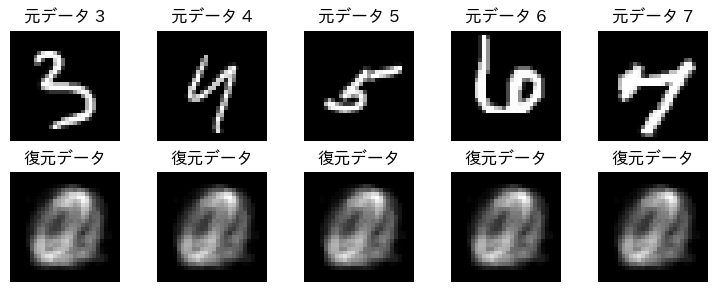

[gram_orth] Label not-a の例 -> [3, 4, 5, 6, 7, 8, 9]


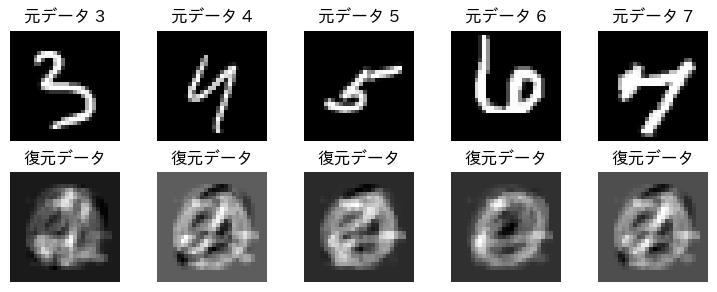

[anchor_local_leak] dataset=mnist, F_type=umap, dim=10, anchors=300, a_label=0, spill_type=local
  pseudo-inverse ACC   : all=0.2630, a=0.5615, not_a=0.1245
  MLP ACC              : all=0.2500, a=0.6435, not_a=0.0673
  Procrustes ACC       : all=0.1400, a=0.1956, not_a=0.1142
  pinv_orth ACC        : all=0.0840, a=0.0978, not_a=0.0776
  pinv_not_orth ACC    : all=0.1020, a=0.0000, not_a=0.1493
  gram ACC             : all=0.1070, a=0.3375, not_a=0.0000
  gram_orth ACC        : all=0.2010, a=0.3722, not_a=0.1215


In [14]:
from config.config import Config

base_config_dict = {
    "name": ["tutorial_mnist"],
    "dataset": [
    #"fashion_mnist",
    "mnist",
    #"mnist_1248",
    #"mice",
    #"statlog",
    #"qsar",
    #"digits",
    #"breast_cancer",
    #"adult",
    #"glass", 
    #"seeds", 
    #"letter_recognition",
    #"wine_quality",
    #"har",
    #"cifar10",
    #'3D_gaussian_clusters',
    #"concentric_three_circles",
    #"iris",
    #"ecoli",
    #"vowel"
    #"medmnist_3",
    #"medmnist_5"
],
    "spill_type": ["local"], # "local", "even", 
    #"spill_label": [[0, 1, 2]],
    "y_name": ["target"],
    "num_institution_user": [1000],
    "data_distribution": ["even"],
    "anchor_method": ["smote"], # "smote"
    "num_anchor_data": [300],
    "spill_label": [[0,1,2]],
    "dim_intermediate": [10],
    "visualize_not_a_labels": [[3,4,5,6,7,8,9]],
    #"spill_num": [300],
    "F_type": ["svd", "umap"], #   "ae", "kernel_pca_self_tuning", "umap"
    "recon_centering": [True],
    "inter_normalization": [False],
    "preprocess":[False],
    "smote_ratio": [1],
    "gamma_ratio": [1.0],
    "public_anchor_num": [100],
    "use_public_anchor": ["spill_label"],
    #"use_public_anchor":[False],
    "seed":[i for i in range(2)],
    "visualize_rec": [True],
    #"visualize_method_list": [["pinv", "pinv_not_orth", "gram", "gram_orth"]],
    "noise_level": [0.0],
}

df_results = run_anchor_local_leak_grid(base_config_dict)
df_results
# 適当な CSV 出力
df_results.to_csv("anchor_local_leak_results.csv", index=False)


In [15]:
from config.config import Config

base_config_dict = {
    "name": ["tutorial_mnist"],
    "dataset": [
    #"fashion_mnist",
    "mnist",
    #"mnist_1248",
    #"mice",
    #"statlog",
    #"qsar",
    #"digits",
    #"breast_cancer",
    #"adult",
    #"glass", 
    #"seeds", 
    #"letter_recognition",
    #"wine_quality",
    #"har",
    #"cifar10",
    #'3D_gaussian_clusters',
    #"concentric_three_circles",
    #"iris",
    #"ecoli",
    #"vowel"
    #"medmnist_3",
    #"medmnist_5"
],
    "spill_type": ["local"], # "local", "even", 
    "spill_label": [[0, 1, 2]],
    "y_name": ["target"],
    "num_institution_user": [100],
    "data_distribution": ["even"],
    "anchor_method": ["real"], # "smote"
    "num_anchor_data": [300],
    "dim_intermediate": [10],
    "F_type": ["svd", "umap"], #   "ae", "kernel_pca_self_tuning", "umap"
    "inter_normalization": [False],
    "preprocess":[False],
    "smote_ratio": [0],
    "gamma_ratio": [1.0],
    "seed":[i for i in range(1)],
    "visualize_rec": [True],
    "public_anchor_num": [1000], #############
    "use_public_anchor":[True],
}

df_results = run_anchor_local_leak_grid(base_config_dict)
df_results
# 適当な CSV 出力
df_results.to_csv("anchor_local_leak_results.csv", index=False)


TypeError: float() argument must be a string or a number, not 'NoneType'

[label counts] user: {1: 14, 0: 12, 7: 12, 8: 12, 2: 11, 4: 11, 9: 10, 6: 9, 3: 5, 5: 4}
[label counts] anchor_pool: {1: 7863, 7: 7281, 3: 7136, 2: 6979, 9: 6948, 0: 6891, 6: 6867, 8: 6813, 4: 6813, 5: 6309}
[pinv] Label a = 0 の例


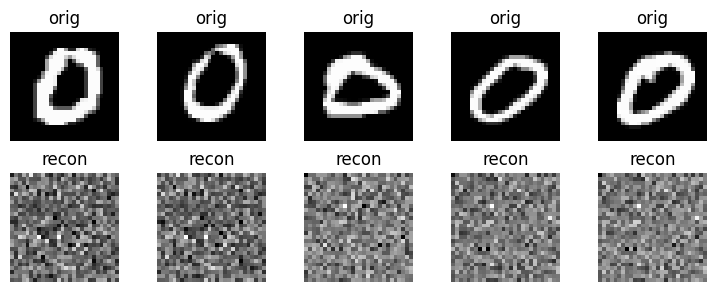

[mlp] Label a = 0 の例


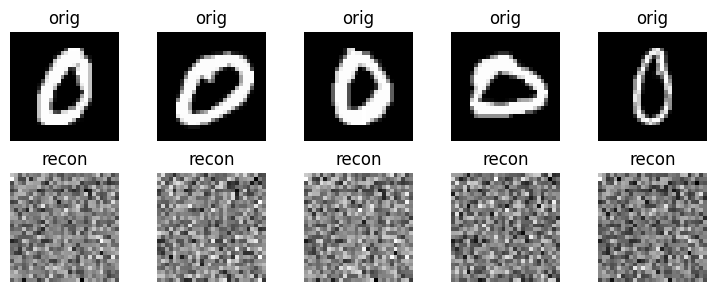

[proc] Label a = 0 の例


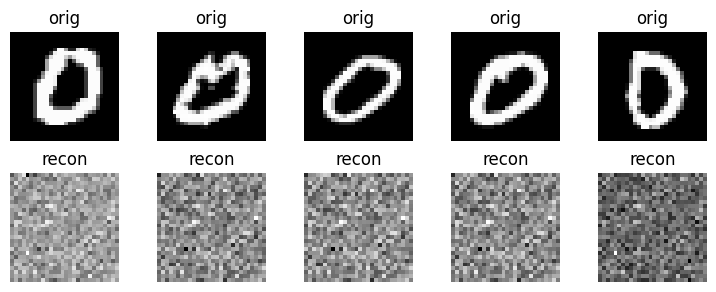

[pinv_orth] Label a = 0 の例


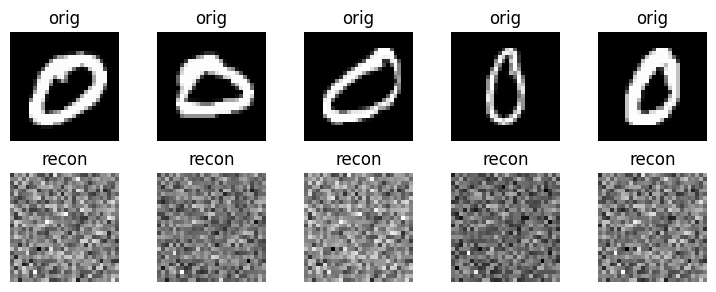

[pinv_not_orth] Label a = 0 の例


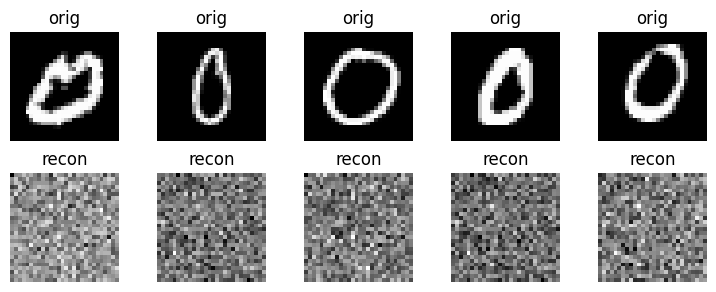

[gram] Label a = 0 の例


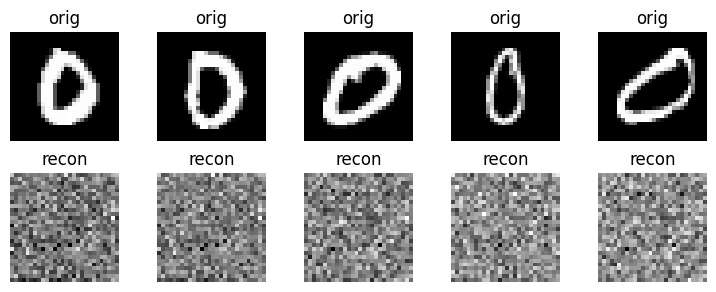

[gram_orth] Label a = 0 の例


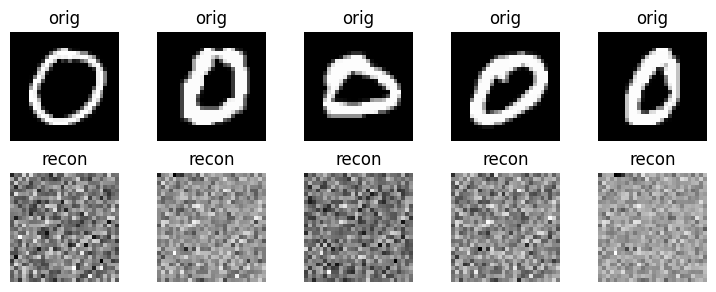

[pinv] Label not-a の例 (pinv)


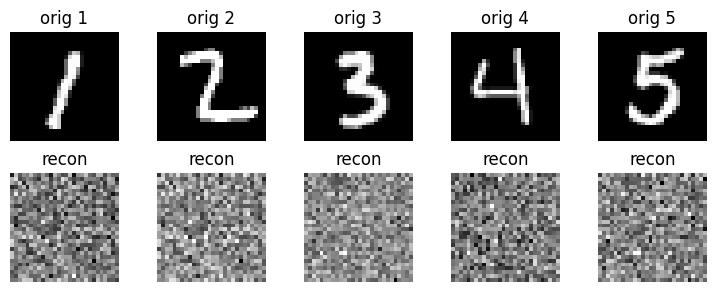

[mlp] Label not-a の例 (mlp)


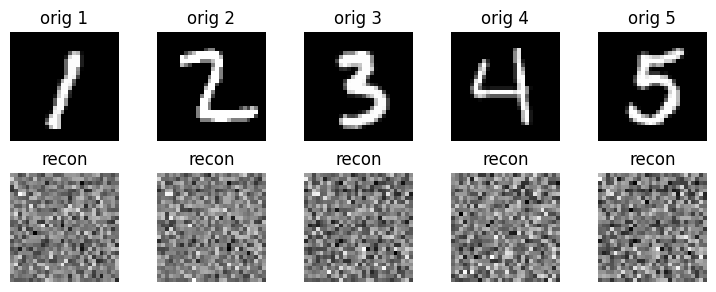

[proc] Label not-a の例 (proc)


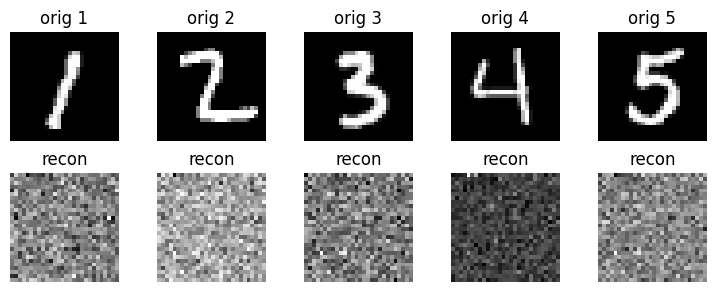

[pinv_orth] Label not-a の例 (pinv_orth)


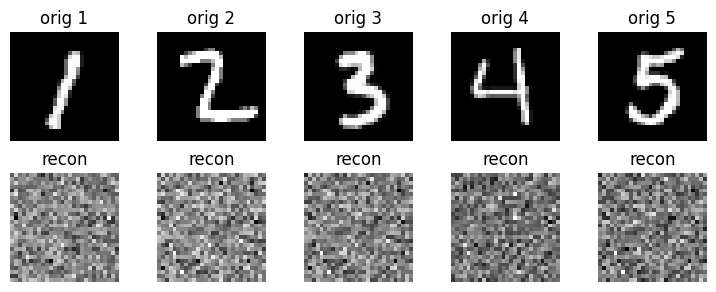

[pinv_not_orth] Label not-a の例 (pinv_not_orth)


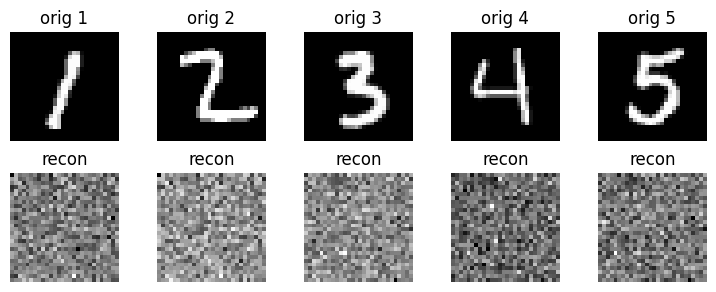

[gram] Label not-a の例 (gram)


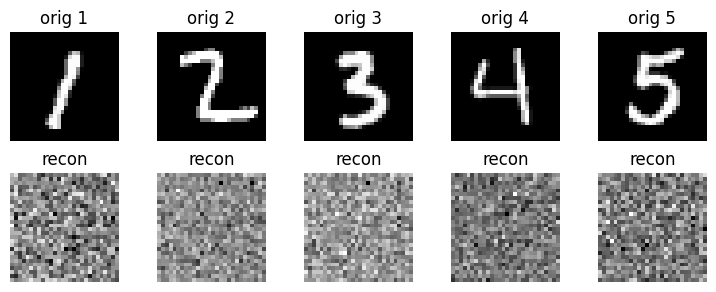

[gram_orth] Label not-a の例 (gram_orth)


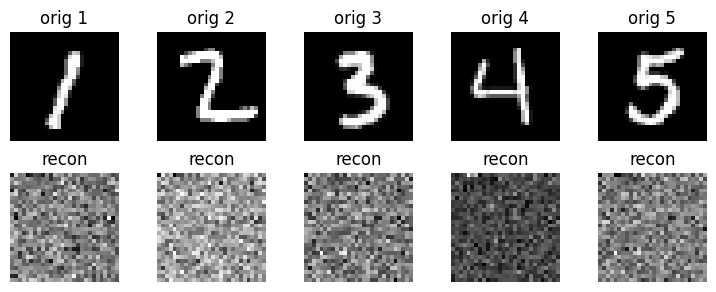

[anchor_local_leak] dataset=mnist, F_type=svd, dim=10, anchors=10, a_label=0, spill_type=random
  pseudo-inverse ACC   : all=0.0700, a=0.0000, not_a=0.0795
  MLP ACC              : all=0.1500, a=0.0000, not_a=0.1705
  Procrustes ACC       : all=0.1000, a=0.0833, not_a=0.1023
  pinv_orth ACC        : all=0.1400, a=0.1667, not_a=0.1364
  pinv_not_orth ACC    : all=0.1000, a=0.0000, not_a=0.1136
  gram ACC             : all=0.0500, a=0.0833, not_a=0.0455
  gram_orth ACC        : all=0.1000, a=0.0833, not_a=0.1023
[label counts] user: {1: 14, 0: 12, 7: 12, 8: 12, 2: 11, 4: 11, 9: 10, 6: 9, 3: 5, 5: 4}
[label counts] anchor_pool: {1: 7863, 7: 7281, 3: 7136, 2: 6979, 9: 6948, 0: 6891, 6: 6867, 8: 6813, 4: 6813, 5: 6309}
UMAP seed: 0


/Users/suetake/git-repos/takano_labo/dca/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[pinv] Label a = 0 の例


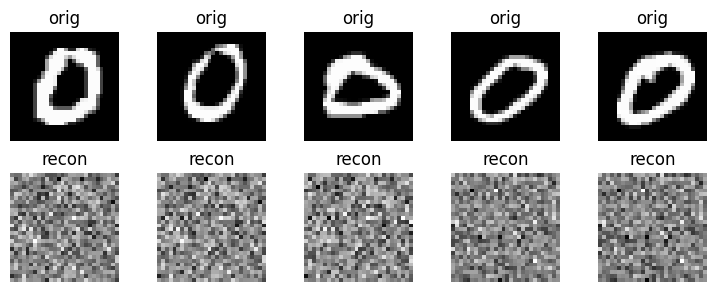

[mlp] Label a = 0 の例


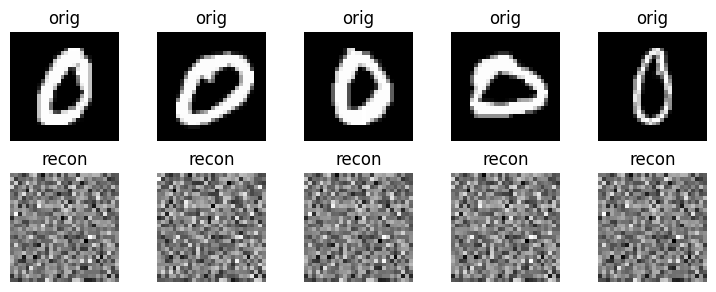

[proc] Label a = 0 の例


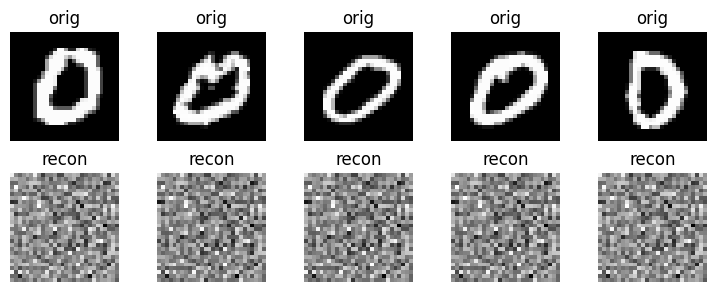

[pinv_orth] Label a = 0 の例


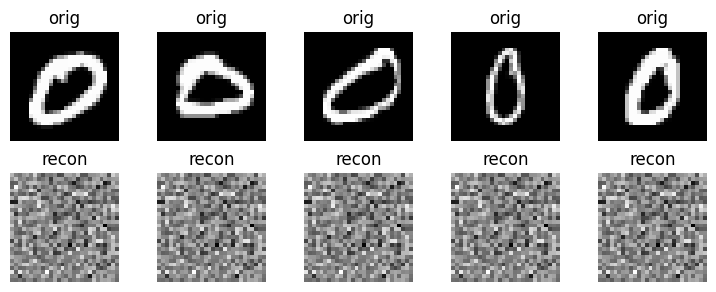

[pinv_not_orth] Label a = 0 の例


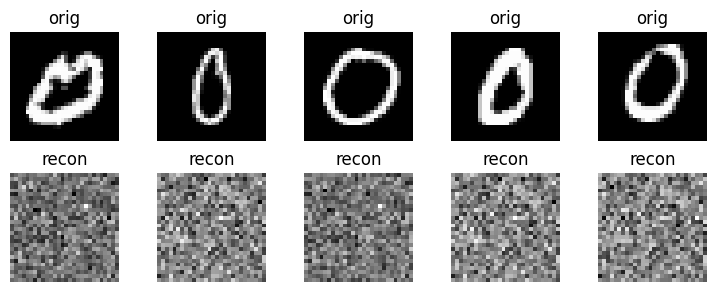

[gram] Label a = 0 の例


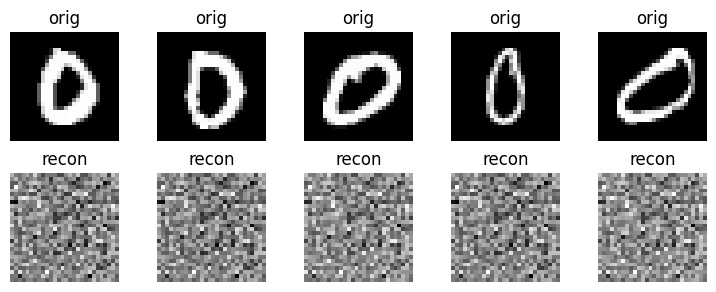

[gram_orth] Label a = 0 の例


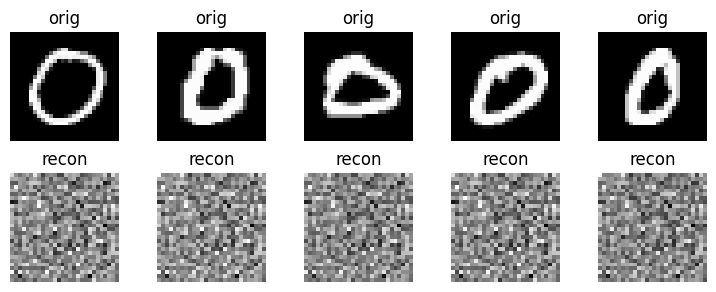

[pinv] Label not-a の例 (pinv)


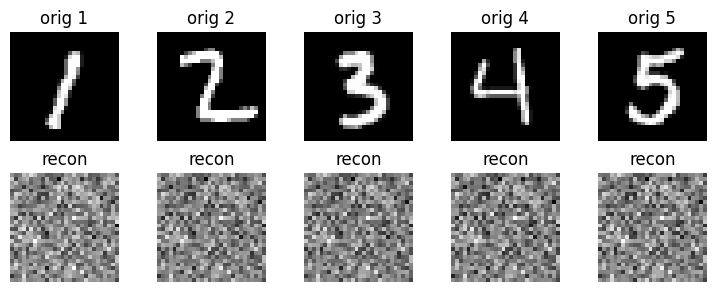

[mlp] Label not-a の例 (mlp)


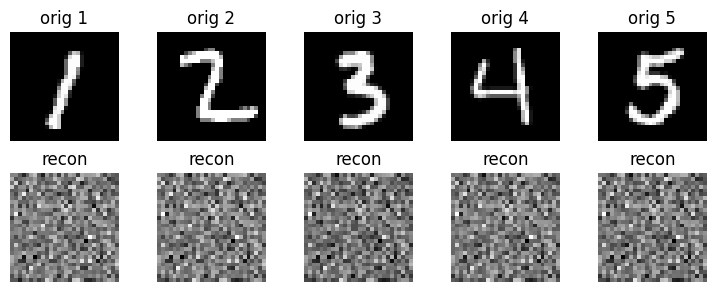

[proc] Label not-a の例 (proc)


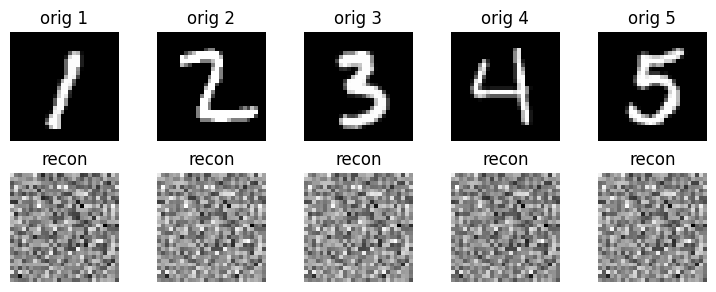

[pinv_orth] Label not-a の例 (pinv_orth)


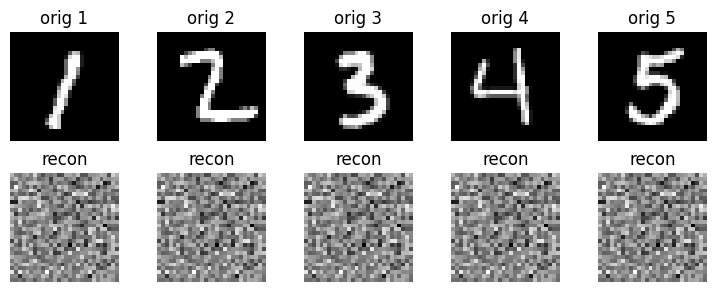

[pinv_not_orth] Label not-a の例 (pinv_not_orth)


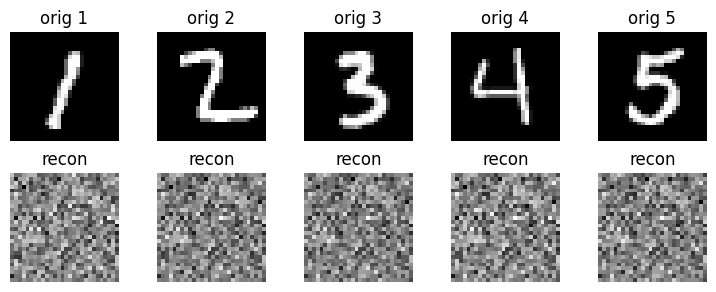

[gram] Label not-a の例 (gram)


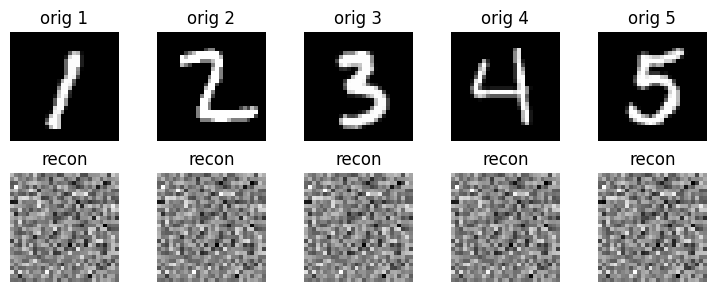

[gram_orth] Label not-a の例 (gram_orth)


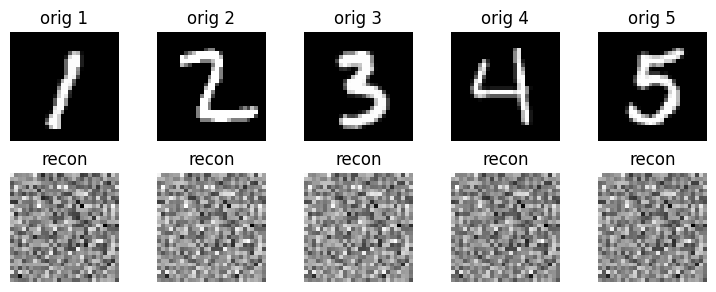

[anchor_local_leak] dataset=mnist, F_type=umap, dim=10, anchors=10, a_label=0, spill_type=random
  pseudo-inverse ACC   : all=0.1000, a=0.5833, not_a=0.0341
  MLP ACC              : all=0.1200, a=0.0000, not_a=0.1364
  Procrustes ACC       : all=0.1200, a=1.0000, not_a=0.0000
  pinv_orth ACC        : all=0.1200, a=0.0000, not_a=0.1364
  pinv_not_orth ACC    : all=0.1200, a=1.0000, not_a=0.0000
  gram ACC             : all=0.1300, a=0.4167, not_a=0.0909
  gram_orth ACC        : all=0.1200, a=1.0000, not_a=0.0000


In [ ]:
from config.config import Config

base_config_dict = {
    "name": ["tutorial_mnist"],
    "dataset": [
    #"fashion_mnist",
    "mnist",
    #"mnist_1248",
    #"mice",
    #"statlog",
    #"qsar",
    #"digits",
    #"breast_cancer",
    #"adult",
    #"glass", 
    #"seeds", 
    #"letter_recognition",
    #"wine_quality",
    #"har",
    #"cifar10",
    #'3D_gaussian_clusters',
    #"concentric_three_circles",
    #"iris",
    #"ecoli",
    #"vowel"
    #"medmnist_3",
    #"medmnist_5"
],
    "spill_type": ["random"], # "local", "even", 
    "y_name": ["target"],
    "num_institution_user": [100],
    "data_distribution": ["even"],
    "anchor_method": ["gaussian"], # "smote"
    "num_anchor_data": [10],
    "dim_intermediate": [10],
    "F_type": ["svd", "umap"], #   "ae", "kernel_pca_self_tuning", "umap"
    "inter_normalization": [False],
    "preprocess":[False],
    "smote_ratio": [0],
    "gamma_ratio": [1.0],
    "seed":[i for i in range(1)],
    "visualize_rec": [True],
    "public_anchor_num": [100], #############
    #"use_public_anchor":[False],
}

df_results = run_anchor_local_leak_grid(base_config_dict)
df_results
# 適当な CSV 出力
df_results.to_csv("anchor_local_leak_results.csv", index=False)


[label counts] user: {1: 14, 0: 12, 7: 12, 8: 12, 2: 11, 4: 11, 9: 10, 6: 9, 3: 5, 5: 4}
[label counts] anchor_pool: {1: 7863, 7: 7281, 3: 7136, 2: 6979, 9: 6948, 0: 6891, 6: 6867, 8: 6813, 4: 6813, 5: 6309}
[pinv] Label a = 0 の例


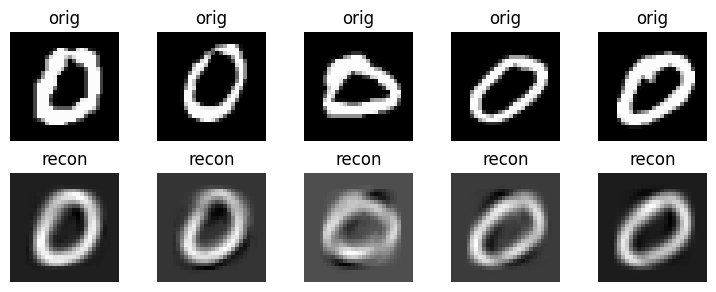

[mlp] Label a = 0 の例


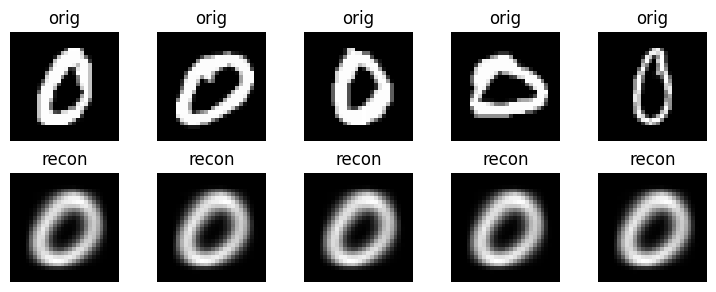

[proc] Label a = 0 の例


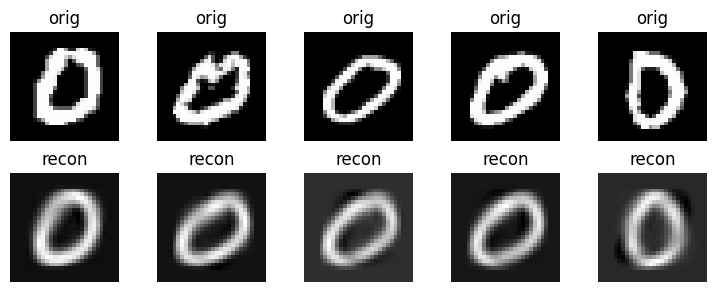

[pinv_orth] Label a = 0 の例


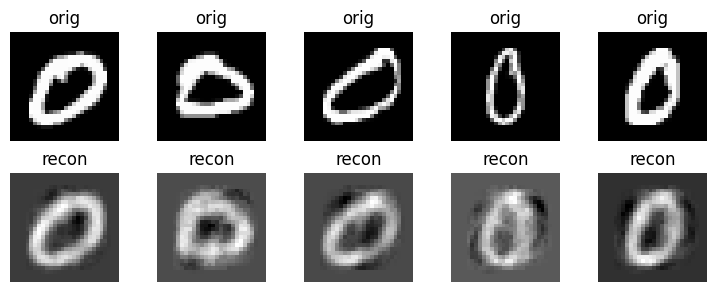

[pinv_not_orth] Label a = 0 の例


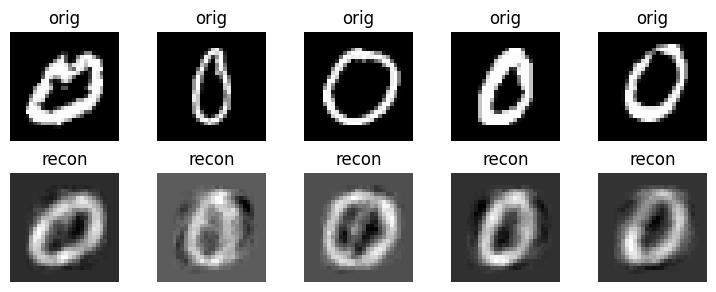

[gram] Label a = 0 の例


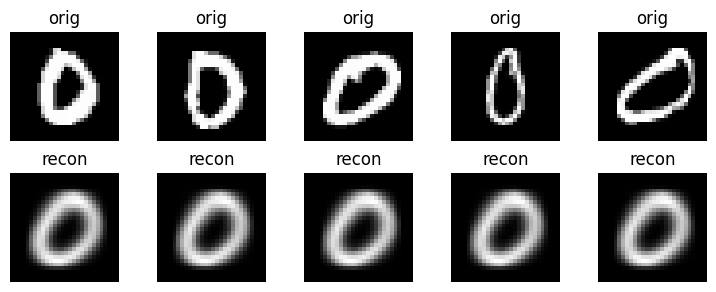

[gram_orth] Label a = 0 の例


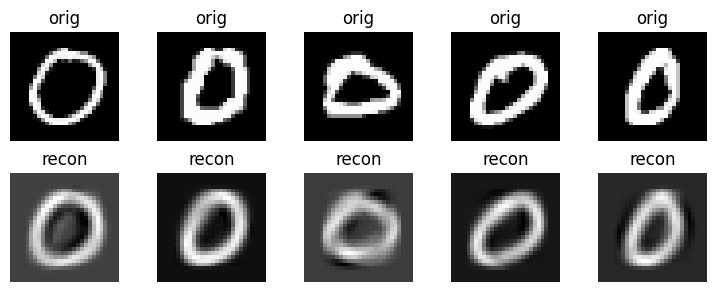

[pinv] Label not-a の例 (pinv)


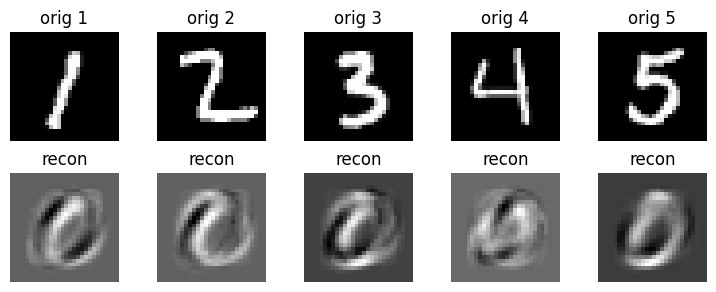

[mlp] Label not-a の例 (mlp)


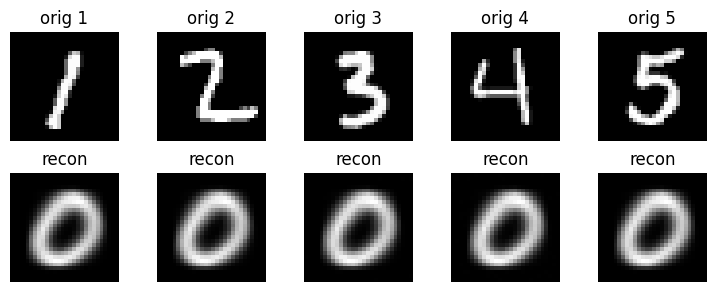

[proc] Label not-a の例 (proc)


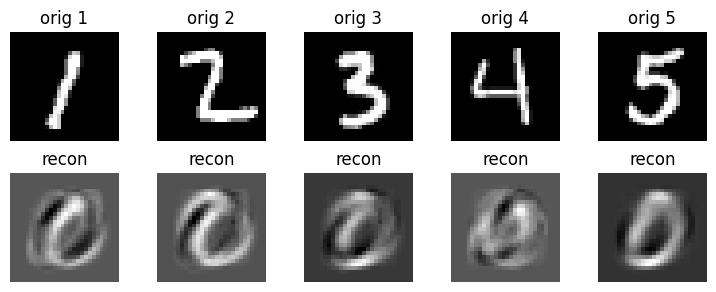

[pinv_orth] Label not-a の例 (pinv_orth)


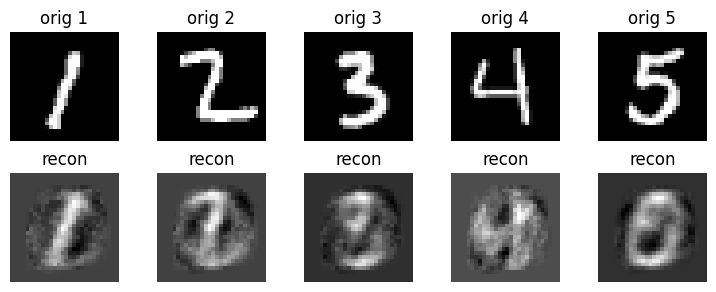

[pinv_not_orth] Label not-a の例 (pinv_not_orth)


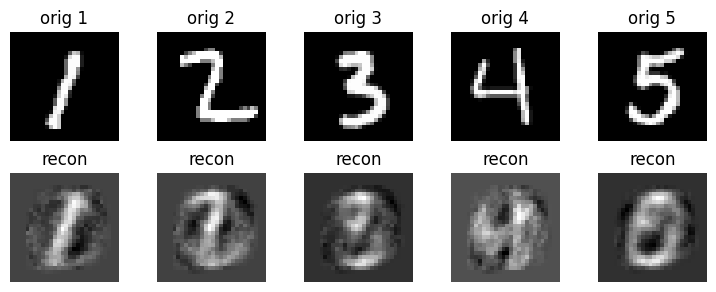

[gram] Label not-a の例 (gram)


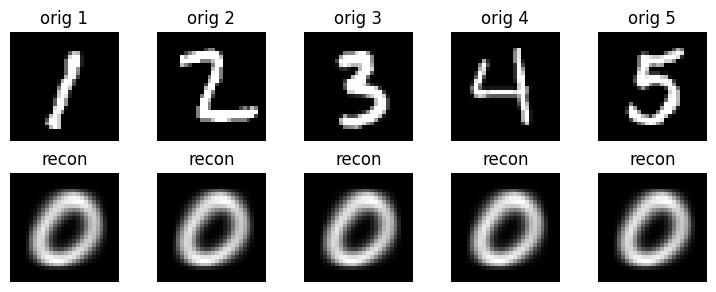

[gram_orth] Label not-a の例 (gram_orth)


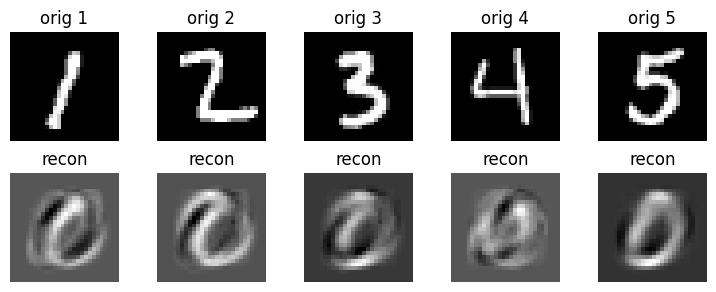

[anchor_local_leak] dataset=mnist, F_type=svd, dim=10, anchors=300, a_label=0, spill_type=local
  pseudo-inverse ACC   : all=0.4800, a=0.8333, not_a=0.4318
  MLP ACC              : all=0.1200, a=1.0000, not_a=0.0000
  Procrustes ACC       : all=0.5200, a=0.9167, not_a=0.4659
  pinv_orth ACC        : all=0.6900, a=0.8333, not_a=0.6705
  pinv_not_orth ACC    : all=0.6900, a=0.8333, not_a=0.6705
  gram ACC             : all=0.1200, a=1.0000, not_a=0.0000
  gram_orth ACC        : all=0.5200, a=0.9167, not_a=0.4659
[label counts] user: {1: 14, 0: 12, 7: 12, 8: 12, 2: 11, 4: 11, 9: 10, 6: 9, 3: 5, 5: 4}
[label counts] anchor_pool: {1: 7863, 7: 7281, 3: 7136, 2: 6979, 9: 6948, 0: 6891, 6: 6867, 8: 6813, 4: 6813, 5: 6309}
UMAP seed: 0


/Users/suetake/git-repos/takano_labo/dca/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[pinv] Label a = 0 の例


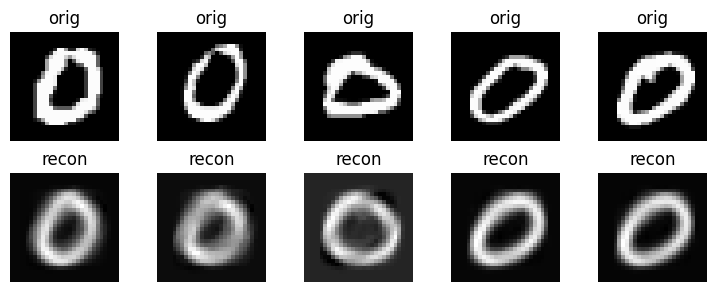

[mlp] Label a = 0 の例


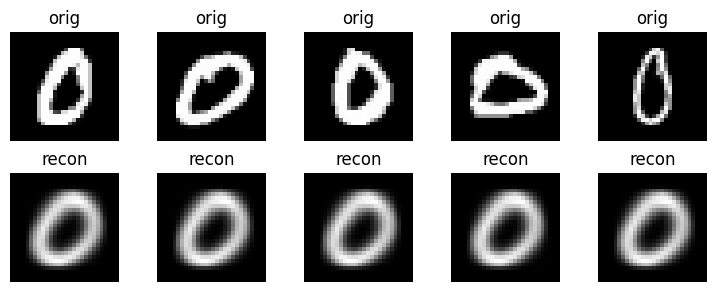

[proc] Label a = 0 の例


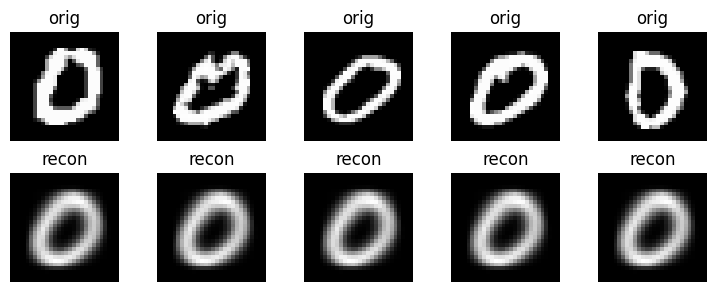

[pinv_orth] Label a = 0 の例


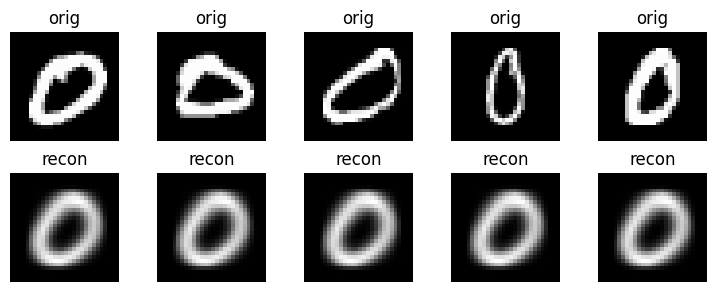

[pinv_not_orth] Label a = 0 の例


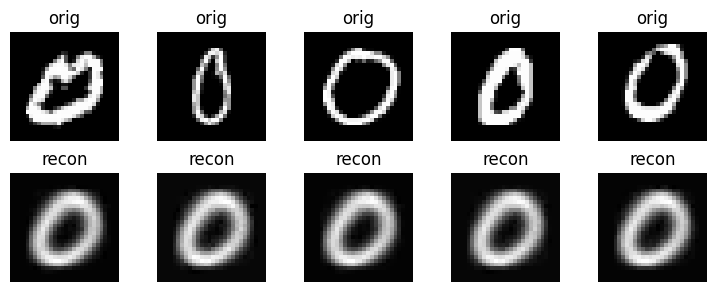

[gram] Label a = 0 の例


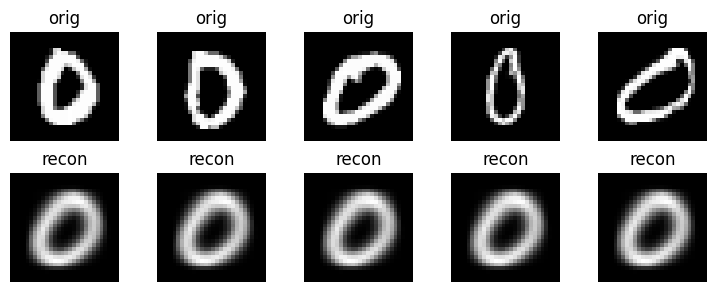

[gram_orth] Label a = 0 の例


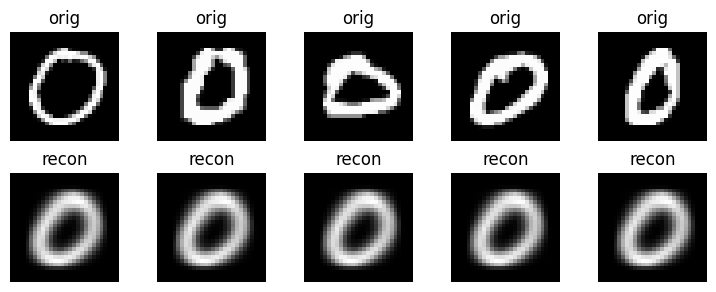

[pinv] Label not-a の例 (pinv)


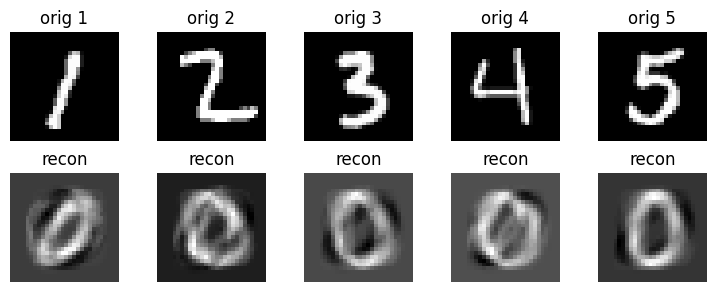

[mlp] Label not-a の例 (mlp)


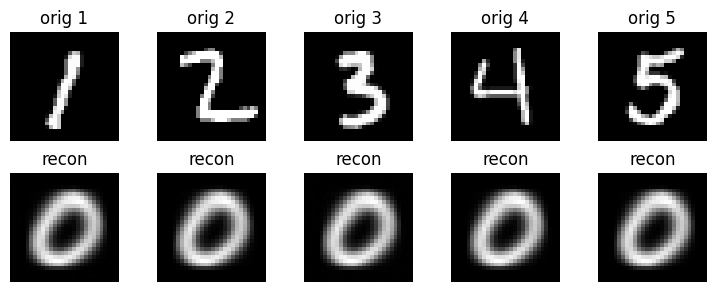

[proc] Label not-a の例 (proc)


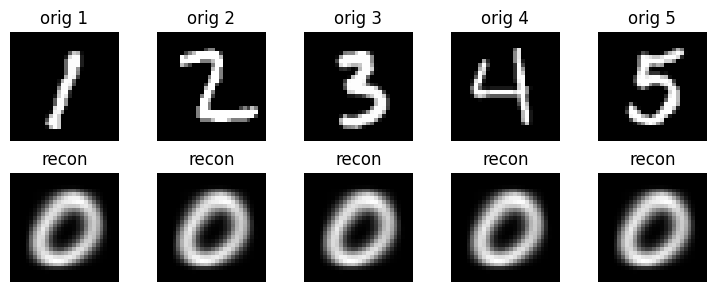

[pinv_orth] Label not-a の例 (pinv_orth)


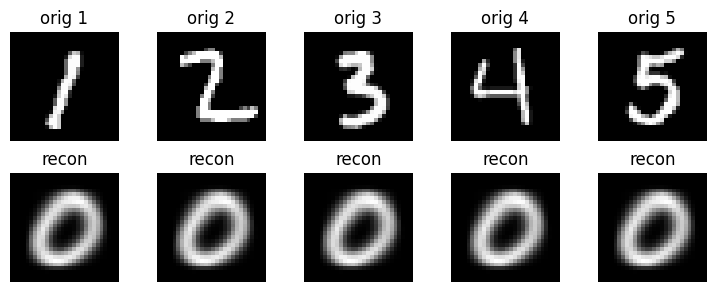

[pinv_not_orth] Label not-a の例 (pinv_not_orth)


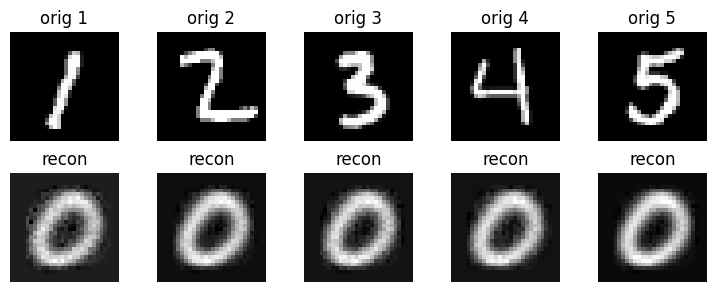

[gram] Label not-a の例 (gram)


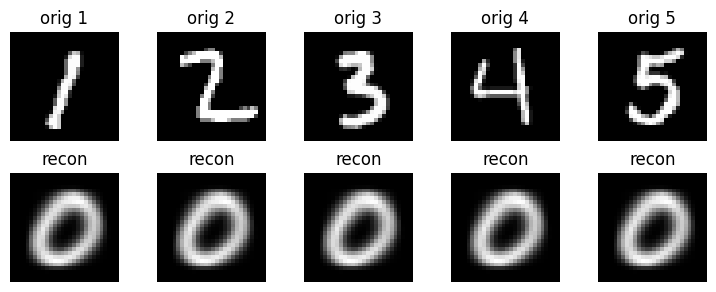

[gram_orth] Label not-a の例 (gram_orth)


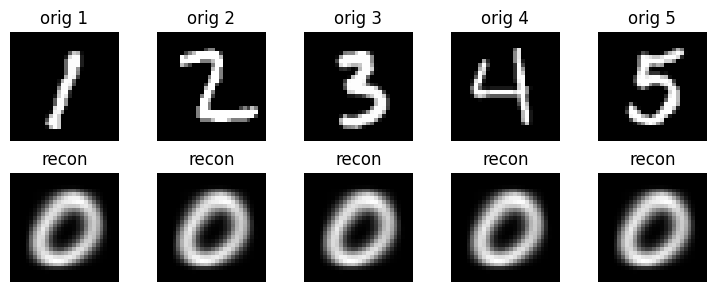

[anchor_local_leak] dataset=mnist, F_type=umap, dim=10, anchors=300, a_label=0, spill_type=local
  pseudo-inverse ACC   : all=0.2100, a=0.9167, not_a=0.1136
  MLP ACC              : all=0.1200, a=1.0000, not_a=0.0000
  Procrustes ACC       : all=0.1200, a=1.0000, not_a=0.0000
  pinv_orth ACC        : all=0.1200, a=1.0000, not_a=0.0000
  pinv_not_orth ACC    : all=0.1200, a=1.0000, not_a=0.0000
  gram ACC             : all=0.1200, a=1.0000, not_a=0.0000
  gram_orth ACC        : all=0.1200, a=1.0000, not_a=0.0000


In [ ]:
from config.config import Config

base_config_dict = {
    "name": ["tutorial_mnist"],
    "dataset": [
    #"fashion_mnist",
    "mnist",
    #"mnist_1248",
    #"mice",
    #"statlog",
    #"qsar",
    #"digits",
    #"breast_cancer",
    #"adult",
    #"glass", 
    #"seeds", 
    #"letter_recognition",
    #"wine_quality",
    #"har",
    #"cifar10",
    #'3D_gaussian_clusters',
    #"concentric_three_circles",
    #"iris",
    #"ecoli",
    #"vowel"
    #"medmnist_3",
    #"medmnist_5"
],
    "spill_type": ["local"], # "local", "even", 
    "spill_label": [[0, 1, 2]],
    "y_name": ["target"],
    "num_institution_user": [100],
    "data_distribution": ["even"],
    "anchor_method": ["real"], # "smote"
    "num_anchor_data": [300],
    "dim_intermediate": [10],
    "F_type": ["svd", "umap"], #   "ae", "kernel_pca_self_tuning", "umap"
    "inter_normalization": [False],
    "preprocess":[False],
    "smote_ratio": [0],
    "gamma_ratio": [1.0],
    "seed":[i for i in range(1)],
    "visualize_rec": [True],
    "public_anchor_num": [1000], #############
    "use_public_anchor":[False],
    "noise_level": [0.0],
}

df_results = run_anchor_local_leak_grid(base_config_dict)
df_results
# 適当な CSV 出力
df_results.to_csv("anchor_local_leak_results.csv", index=False)
